In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from dolfyn.adv import clean as dclean   # dolfyn 1.3.0, dolf_env kernel

# ADV QC
Steps, in the order they are applied:
1. clock drift correction (whole raw record, before anything else)
2. trim to in-water start/end, atmospheric pressure correction, configured salinity (sound speed)
3. beam quality: correlation gate 0.3 + 0.4 sqrt(fs/25) and SNR < 8 dB flag (Elgar et al. 2001, 2005)
4. Elgar replacement (runs <= 1 s linear, longer = 1-s running mean; `vel_qc_flag`) + hourly segment flags
5. rotation to earth / shore-normal (KVH heading + declination)
6. z² test (Elgar et al. 2005, §3.3): measured vs velocity-predicted pressure variance, 0.05-0.20 Hz, per hour;
   hours outside 0.5 < z² < 2.0 fail `seg_ok`

Input: `data/processed/{sensor}_raw.nc`. Output: one file, `data/processed/qc/{sensor}_QC.nc`, written
at the end (section 7). No intermediate files are saved.

Guidelines for QC taken from Holden's PUV QC workflow 


### 0. Sensor selection and parameters
VC5 is the test sensor. Every section reads `sensor_id` from the cell below, so a single run only
needs that one line changed. Once the pipeline is verified on VC5, list the other sensors in
`SENSORS` and use the batch cell at the end of the notebook ("Run the other sensors"), which
executes this notebook once per sensor and keeps an executed copy of each for review.

In [2]:
##-----sensor selection-----##
sensor_id = "VC5"
# Sensors for the batch cell at the end of the notebook. Only VC5 until the pipeline is verified.
# All processed Vectors: ["VA10", "VB5", "VC5", "VC10", "VD5", "VD10", "VE4", "VE7", "VE10"]
# (VE4's clock drift is footnoted in sensor_notes.csv; resolved in DRIFT_OVERRIDE below.)
SENSORS = ["VA10", "VB5", "VC5", "VC10", "VD5", "VD10", "VE4", "VE7", "VE10"]

##-----parameters-----##
# Everything tunable lives here.
# section 1: clock drift
# Drifts (s, + = sensor clock fast) that replace a footnoted "*" value in sensor_notes.csv.
DRIFT_OVERRIDE = {
    # CSV "+6.126*": measured 36006.126 s with the download PC still on Hawaii time (UTC-10). The
    # sensor ran on UTC (record starts 07-18 05:46, with the other sensors; tide lag 0 min), so the
    # drift is the remainder, +6.126 s. The wave-band lag against VE7 trends -1.3 s over the
    # deployment, which implies about +8 s. That rules out -6.126 s (which would give -15.4 s); the
    # method's error on the control pairs is 2-6 s, so it cannot resolve 6.1 from 8.
    "VE4": +6.126,
}

# section 2: trim + pressure + sound speed
P_WET        = 3.0    # dbar. Below this the instrument is out of the water. In air it reads
                      # ~0.8-1.0 dbar and the shallowest Vector sits at ~4 m, so 3 dbar
                      # separates the two cleanly.
# Manual pressure edges (start, end), for sensors where the longest-wet-run rule fails. Handling edges
# and BUFFER_S are still applied inside them.
TRIM_EDGES   = {
    # ~4.5 m deep: wave troughs drop p below P_WET in big swell, splitting the record into 300 wet
    # runs; the longest was only 07-24 -> 08-16 (22.7 of ~57 days). First/last wet samples:
    "VB5": ("2026-07-19 21:48:49", "2026-09-15 20:53:21"),
}
BUFFER_S     = 10     # s taken off each end of the window, AFTER the handling edges
HEAD_STD_MAX = 0.25   # deg. Floor of the handling threshold on the 1-min circular heading std
HEAD_STD_K   = 3.0    # threshold = max(HEAD_STD_MAX, HEAD_STD_K * median 1-min std of this sensor).
                      # Compass noise differs by sensor (median VC10 0.09 deg, VC5 0.23 deg), while
                      # handling gives > ~0.7 deg. The median, not the std, sets the scale: the
                      # handling minutes themselves inflate the std 20-30x (VC5: std 0.46, MAD 0.02).
CALM_MIN_MIN = 30     # min. A calm stretch must last this long to count as "deployed"
P_AIR        = 1.5    # dbar. Below this the instrument is in air, used for the in-air offset.
                      # Excludes readings taken while the frame hung below the boat (~2.6 dbar on VC10).
S_TRUE       = 35.0   # PSU, ASSUMED ambient salinity; the instrument was configured with 33.5.
                      # Replace with a measured value (CTD/RBR) if one exists.
RHO, GRAV    = 1023.0, 9.79   # kg/m3, m/s2 (21 N): dbar -> m of water, 1 dbar = 1e4 Pa

# section 3: beam quality (Elgar, Raubenheimer & Guza 2001 JTECH 18; 2005 MST 16, lit/)
CORR_A, CORR_B   = 0.30, 0.40   # min beam correlation = CORR_A + CORR_B * sqrt(fs / CORR_REF_FS), as a fraction.
CORR_REF_FS      = 25.0         # Hz. 0.7 at 25 Hz (SonTek recommendation), relaxed as sqrt(fs) because the
                                # Vector averages more pings (internal 100-250 Hz) into each slower sample.
                                # 41.3 % at 2 Hz. Computed in section 3, where fs is known.
AMP_DB_PER_COUNT = 0.43   # dB per amplitude count (Nortek), for SNR = 0.43 * (amp - noise floor)
SNR_MIN          = 8.0    # dB. Elgar et al. 2005 value for NorTek Vectors
SNR_RUN_FRAC     = 0.0081 # Elgar et al. 2005: a run fails if > 0.81 % (25*fs samples per 3072 s) are low SNR.
                          # Stored as the hourly flag seg_snr_ok; NOT applied (see section 3 notes)
APPLY_SNR        = False  # True also gates velocity per sample where any beam is below SNR_MIN

# section 4: Elgar replacement of low-correlation samples (no despiking: tested, at 2 Hz in waves it
# removed real crests)
ELGAR_INTERP_MAX_S = 1.0  # s. Runs this short or shorter are linearly interpolated (Elgar: "< 1 s"; at 2 Hz
                          # a 2-sample run is exactly 1 s, and is interpolated too)
ELGAR_RUNMEAN_S    = 1.0  # s. Longer runs get a running mean of this span over the RECORDED values
RUNMEAN_MAX_FRAC   = 0.10 # 1-h segments (and Z-test segments) with more running-mean samples fail seg_ok
NAN_MAX_FRAC       = 0.10 # lab nanMaxFrac: Z-test segments with more NaN (e.g. in p) are skipped

# section 5: rotation
DECLINATION_DEG  = 9.26   # deg, + = east. WMM-2025 at 21.297 N, 158.042 W on 2026-08-15 (NOAA NCEI
                          # calculator; uncertainty 0.33 deg; IGRF-14 gives 9.27). It changes -0.04 deg/yr
                          # and < 0.01 deg across the array, so one value covers every sensor and the record.
HEAD_UP          = True   # probe heads point up (field note 2026-09-18). In Nortek XYZ that makes +Z point
                          # DOWN (+Y 90 deg clockwise of +X from above), i.e. roll = 180. Checked on the
                          # data in section 5 (w vs dp/dt).
SHORE_NORMAL_OVERRIDE = None  # deg true, onshore-pointing. None = use this sensor's transect value from
                          # sensor_notes.csv ("Shore Normal Onshore (deg true)" = shoreline heading W->E
                          # minus 90; A 355, B 336, C 350, D 339, E 3). Set a number only to test another
                          # angle. Section 5 prints the wave and mean-current estimates to compare against.

# section 6: z^2 test (Elgar, Raubenheimer & Guza 2005, MST 16, section 3.3), one value per clock hour
ZT_F_Z2    = (0.05, 0.20)  # Hz, wind-wave band over which z^2 is integrated (Elgar et al. 2005)
ZT_WINDOW  = (0.5, 2.0)    # an hour is rejected (seg_ok False) unless 0.5 < z^2 < 2.0 (Elgar et al. 2005)
ZT_NFFT    = 256           # samples (128 s). Welch window inside an hour, Hann, ~55 windows -> ~100 dof
ZT_OVERLAP = 0.5           # Welch overlap
ZT_F_SS    = (0.04, 0.25)  # Hz, sea-swell band for Hs_SS only (lab fSS)
ZT_F_IG    = (0.004, 0.04) # Hz, infragravity band (lab fIG) for z2_IG. Only ~5 bins at df = 0.0078 Hz, diagnostic
ZT_MIN_SEG = 20            # fewer valid hours than this = record status "insufficient"
Z_P_HAB    = 0.05          # m, pressure port above the bed (d_p in Elgar's Eq. 1; < 0 = buried). ESTIMATE (lab
                           # HI26_config doffp, "pending DeploymentNotes"). Sets the total depth h = mean p + Z_P_HAB.
Z_U_HAB    = None          # m, velocity sampling volume above the bed (d_u). None = same as Z_P_HAB (the lab's
                           # co-located assumption). z^2 moves < 0.3 % for 0-0.7 m on VC5/VE10 (printed below).

# paths: data/processed/{sensor}_raw.nc in, data/processed/qc/{sensor}_QC.nc out, figs/qc/ for QC figures
data_path = "/Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed"
root    = Path(data_path).parents[1]              # .../4EWA
qc_dir  = Path(data_path) / "qc"
fig_dir = root / "figs" / "qc"
qc_dir.mkdir(exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# figure style
INK, INK2, GRID, SERIES = "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"
BEAM_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]   # beams 1, 2, 3 (fixed order)
plt.rcParams.update({
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2,
    "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white", "font.size": 9,
})

### 1. Clock Drift Correction
 - assumed linear drift from 0 at start to the measured drift at recovery, as linspace over the record. Check
   the CSV sign convention: negative means the sensor clock is slow, so corrected $ time = t − drift·(fraction elapsed)$ only when that sign is respected.



#### 1a. Load, drop seam fillers, linear drift correction

1. **Drop seam filler records.** At each `.vec` file boundary, and after the recorder was stopped,
   the reader emits placeholder samples with `p = 0`, all beam correlations `= 0`, `temp = NaN`
   and a timestamp that duplicates the next real sample. Left in, they read as "out of water"
   mid-deployment. They are dropped, not interpolated.
2. **Linear drift.** The drift in `sensor_notes.csv` is the instrument clock minus PC internet
   time, measured at download. `+` = sensor clock fast, `-` = slow. The error builds up roughly
   linearly from when the clock was set (≈ first raw sample) to when it was checked (≈ last raw
   sample: logging stopped when the instrument was connected to the Nortek software). So each
   sample is shifted by
   `t_true = t - drift * (t - t_raw_start) / (t_raw_end - t_raw_start)`.
  

The tide-gauge check of the corrected clock needs the atmosphere-corrected pressure, so it runs
at the end of section 2 (2b).

In [3]:
##-----load raw + drop seam filler records-----##
# .load() pulls the whole file into memory (~400 MB for 10.7 M samples). Everything below
# indexes it repeatedly, and that is much faster in memory than lazily from disk.
ds_raw = xr.open_dataset(Path(data_path) / f"{sensor_id}_raw.nc").load()
n_raw = ds_raw.sizes["time"]

# Seam fillers: pressure exactly 0, all three beam correlations 0, temp NaN, and a timestamp

filler = (ds_raw.p.values == 0) & (ds_raw["corr"].values == 0).all(axis=0)   # corr is (beam, time)
ds = ds_raw.isel(time=~filler)

# check the time base afterwards: spacing should be 0.5 s (2 Hz). Any > 0.5 s is a real gap
# where a filler replaced a sample, rather than duplicating one.
dt = np.diff(ds.time.values) / np.timedelta64(1, "s")
print(f"{sensor_id}: dropped {filler.sum()} filler samples "
      f"(p = 0, corr = 0) of {n_raw:,}")
print(f"  sample spacing after drop: min {dt.min():.3f} s, max {dt.max():.3f} s, "
      f"{(dt > 0.51).sum()} gap(s) > 0.5 s")

VC5: dropped 511 filler samples (p = 0, corr = 0) of 10,676,035
  sample spacing after drop: min 0.500 s, max 1.000 s, 2 gap(s) > 0.5 s


In [4]:
ds

<xarray.Dataset> Size: 502MB
Dimensions:              (x: 3, x*: 3, time: 10675524, beam: 3, earth: 3,
                          inst: 3)
Coordinates:
  * x                    (x) int64 24B 1 2 3
  * x*                   (x*) int64 24B 1 2 3
  * time                 (time) datetime64[ns] 85MB 2026-07-18T06:00:02.99999...
  * beam                 (beam) int64 24B 1 2 3
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables:
    beam2inst_orientmat  (x, x*) float32 36B 2.706 -1.404 ... 0.3525 0.3281
    heading              (time) float32 43MB 217.9 217.9 217.9 ... 36.7 36.65
    pitch                (time) float32 43MB 19.3 19.35 19.4 ... -19.5 -19.45
    roll                 (time) float32 43MB -165.9 -165.9 ... -164.0 -164.0
    temp                 (time) float32 43MB 22.5 22.51 22.52 ... 26.65 26.65
    orientation_down     (time) bool 11MB True True True True ... True True True
    amp                  (beam, time) uint8 32MB 43 43 43 43 43 ... 46 46 47 46
    corr                 (beam, time) uint8 32MB 4 7 3 2 4 6 2 ... 4 3 3 7 6 4 8
    p                    (time) float32 43MB 0.648 0.647 0.648 ... 0.598 0.601
    u                    (time) float32 43MB 0.668 -5.74 -6.197 ... 1.418 -1.742
    v                    (time) float32 43MB 4.914 -0.725 1.766 ... -5.708 3.771
    w                    (time) float32 43MB 1.068 0.63 0.423 ... -0.036 0.489
Attributes: (12/64)
    inst_make:                      Nortek
    inst_model:                     Vector
    inst_type:                      ADV
    rotate_vars:                    vel
    n_beams:                        3
    profile_mode:                   continuous
    ...                             ...
    shore_normal_onshore_deg_true:  350.0
    sensor_assignment:              7
    deployment_site_name:           7-PUV
    clock_drift_sec:                1.07
    pc_used_for_download:           Julia's Lidar Laptop
    original_download_location:     SSD2 (D:) \ Hawaii_Sep2026_Vector

In [5]:
##-----clock drift: linear correction-----##
# drift from the deployment notes. 
notes = pd.read_csv(root / "data" / "metadata" / "sensor_notes.csv", dtype=str, skipinitialspace=True)
notes.columns = notes.columns.str.strip()
row = notes[notes["Processed Data Sensor Name (.nc file)"].str.strip() == sensor_id].iloc[0]
drift_str = row["Clock Drift (seconds) over Deployment Duration***"].strip()
if sensor_id in DRIFT_OVERRIDE:
    drift = float(DRIFT_OVERRIDE[sensor_id])
    print(f"{sensor_id}: DRIFT_OVERRIDE {drift:+.3f} s replaces the CSV value '{drift_str}'")
else:
    assert not drift_str.endswith("*"), f"{sensor_id} drift '{drift_str}' is footnoted; check sensor_notes.csv"
    drift = float(drift_str)        # s; + = sensor clock fast, - = slow (CSV convention)

# The drift builds up over the whole time the clock ran, so the fraction elapsed is measured on
# clock set ~ first sample, drift checked ~ last sample.
t_raw0, t_raw1 = ds_raw.time.values[[0, -1]]
t_old = ds.time.values
frac  = (t_old - t_raw0) / (t_raw1 - t_raw0)          # 0 at clock set -> 1 at drift check
shift = drift * frac                                    # s to subtract from each timestamp
ds = ds.assign_coords(time=t_old - np.round(shift * 1e9).astype("timedelta64[ns]"))

ds.attrs.update({
    "qc_clock_drift_s": drift,
    "qc_clock_drift_convention": "+ = sensor clock fast; t_true = t - drift * frac_elapsed",
    "qc_clock_raw_start": str(t_raw0),
    "qc_clock_raw_end": str(t_raw1),
    "qc_clock_applied": "before trimming, over the full raw record",
})

print(f"{sensor_id}: drift {drift:+.3f} s over the raw record {t_raw0} -> {t_raw1} "
      f"({(t_raw1 - t_raw0) / np.timedelta64(1, 'D'):.2f} days)")
print(f"  shift applied: {shift[0]:+.3f} s (first raw sample) to {shift[-1]:+.3f} s (last)")

VC5: drift +1.070 s over the raw record 2026-07-18T06:00:02.999992132 -> 2026-09-18T00:46:59.554846048 (61.78 days)
  shift applied: +0.000 s (first raw sample) to +1.070 s (last)


### 2. Trim to in water start/end

- use p < 3 dbars, plus a buffer of 10 seconds before and after to trim the data to when the instrument is in water.
- in air pressure at the start will give the original pressure-sensor offset. **However** due to low pressure from moving hurricanes, the atmospheric pressure may have to be adjusted during mid deployment. Pull barometric pressure from NOAA
- Sound speed/salinity corrections 

Notes:
1. **Drop seam filler records**: Each .vec file has a 1s seam filler where p=0 and all beam corrs =0. Dropped in section 1.

2. **Trip to in water**
    - *pressure*: use p < 3 dbars, plus a buffer of 10 seconds before and after to trim the data to when the instrument is in water.
    - *handling edges*: Compute the std of the heading. If the std > 0.25 deg over 60s, assume the instrument is being handled and trim that data. 
3. **Atmospheric Pressure**: take `Patm(t)` from NOAA COOPS barometer at station 1612340, Honolulu Harbor (21.3033 N, 157.8645 W; ~18 km E of VC10), interpolated to each sample.

4.  **Sound speed.** The Vector computed c from its own temperature and the configured salinity
   (33.5), and velocity scales linearly with c. Rescale by `c(T, S_TRUE) / c(T, 33.5)` using
   Medwin (1975). `S_TRUE` is an **assumed** open-coast value; replace it with a measured salinity
   if one exists. The effect is only ~0.1 %.

#### 2a. Trim + pressure/sound-speed corrections

Input is the drift-corrected record from section 1. What these cells do, in order:
1. **In-water window, two stages.**
   - *Pressure edges:* the longest contiguous run with `p >= P_WET`. Using the longest run, not
     the first/last wet sample, ignores lone handling blips after recovery (VC10 had one 3.1 dbar
     sample on 09-18).
   - *Handling edges:* the pressure edges keep diver handling. Divers can move the frame after it
     lands (VC10: heading swung 95 → 32 deg in the first 40 min) and handle it before the lift.
     Undisturbed, the 1-min heading std is ~0.1 deg on VC10 but ~0.23 deg on VC5; handling gives
     > ~0.7 deg. So the threshold is relative to each sensor's own compass noise:
     `max(HEAD_STD_MAX, HEAD_STD_K × median 1-min std)` (0.27 deg on VC10, 0.68 deg on VC5). The
     median is used rather than the std because the handling minutes inflate the std 20–30×.
     The window is shrunk to the first/last **calm** run (1-min std < threshold) lasting at least
     `CALM_MIN_MIN`. A disturbance must last at least 2 min to count, which ignores isolated
     one-sample compass glitches. `BUFFER_S` is then taken off each end.
2. **Atmospheric pressure.** The Vector reads `p_raw = P_abs - C`, with `C` a fixed internal offset.
   In air, `C = Patm - p_raw`, so `p = p_raw + C - Patm(t)` (water pressure only). `Patm(t)` is the
   hourly NOAA CO-OPS barometer at station 1612340, Honolulu Harbor (21.3033 N, 157.8645 W;
   ~18 km E of the array), interpolated to each sample. The drift-corrected clock is taken as UTC.
   The evidence is the tide-gauge lag in 2b (≈ 0 min), which would be ±600 min for a Hawaii-time clock.
   `C` is the median of `Patm - p_raw` over the pre-deployment in-air samples (`p_raw < P_AIR`,
   5 min clear of the splash). The same number from the post-recovery in-air samples gives the
   sensor-zero drift `C_pre - C_post`, which is reported but **not applied**. Waves are unaffected;
   only the absolute mean level depends on `C`.
3. **Sound speed.** The Vector computed c from its own temperature and the configured salinity
   (33.5), and velocity scales linearly with c. Rescale by `c(T, S_TRUE) / c(T, 33.5)` using
   Medwin (1975). `S_TRUE` is an **assumed** open-coast value; replace it with a measured salinity
   if one exists. The effect is only ~0.1 %.

In [6]:
##-----in-water window-----##
# Two stages:
#   1. PRESSURE edges: when the instrument is physically underwater (p >= P_WET).
#   2. HANDLING edges: when it is sitting undisturbed on the bed. Divers move and adjust the
#      frame after it lands and before it is lifted. That shows up as heading jitter, not
#      pressure, so the window is pulled in to where the heading is steady.
t = pd.DatetimeIndex(ds.time.values)
p_raw = ds.p.values
wet = p_raw >= P_WET

def runs(mask):
    # (start, stop) index pairs of True runs, stop inclusive.
    # Padding with 0 on both sides makes diff = +1 at every run start and -1 one past every end.
    e = np.flatnonzero(np.diff(np.r_[0, mask.astype(int), 0]))
    return e[::2], e[1::2] - 1

# --- stage 1: pressure edges ---
# Take the LONGEST wet run rather than the first/last wet sample: a lone post-recovery
# handling blip (VC10: one 3.1 dbar sample on 09-18) would otherwise stretch the window by days.
starts, stops = runs(wet)
k = np.argmax(stops - starts)
i_in, i_out = starts[k], stops[k]          # indices of first/last wet sample of the deployment
print(f"  {len(starts)} wet run(s); longest {t[i_in]} -> {t[i_out]} "
      f"({(t[i_out] - t[i_in]) / pd.Timedelta(hours=1):,.1f} h)")
if sensor_id in TRIM_EDGES:
    # manual edges: first/last WET sample inside the hard-coded span
    e0, e1 = (pd.Timestamp(x) for x in TRIM_EDGES[sensor_id])
    in_span = np.flatnonzero(wet & (t >= e0) & (t <= e1))
    i_in, i_out = in_span[0], in_span[-1]
    print(f"  TRIM_EDGES override for {sensor_id}: {e0} -> {e1}")

# --- stage 2: handling edges ---
# Heading is an angle, so average it on the unit circle: 1-min means of sin and cos, then
# circular std = sqrt(-2 ln R), where R is the mean resultant length (R = 1 means no spread).
# A plain std would blow up whenever the heading crosses 0/360.
hr = np.radians(ds.heading.values[i_in:i_out + 1])
hm = (pd.DataFrame({"s": np.sin(hr), "c": np.cos(hr)}, index=t[i_in:i_out + 1])
        .resample("1min").mean())
R = np.hypot(hm.s, hm.c).clip(upper=1)      # clip guards log() against float round-off above 1
head_std = pd.Series(np.degrees(np.sqrt(-2 * np.log(R))), index=hm.index)

# A minute is "busy" if its heading std exceeds the threshold AND a neighbouring minute
# does too. Requiring >= 2 minutes in a row ignores the isolated one-sample compass glitches
# (~16 deg) that appear mid-record and have nothing to do with handling.
# Threshold relative to this sensor's own compass noise (median over the wet run; the handling
# minutes are too few to move the median), with HEAD_STD_MAX as a floor.
head_thr = max(HEAD_STD_MAX, HEAD_STD_K * float(head_std.median()))
busy = (head_std > head_thr).values
busy = busy & (np.r_[busy[1:], False] | np.r_[False, busy[:-1]])

# Calm runs lasting at least CALM_MIN_MIN minutes. The FIRST one marks the frame settling
# after deployment, the LAST one the final undisturbed minute before recovery. Anything in
# between (storms, fish, the VD10-style heading steps) is left for the tilt/attitude QC.
c0, c1 = runs(~busy)
long_calm = (c1 - c0 + 1) >= CALM_MIN_MIN
if not long_calm.any():
    raise RuntimeError(f"{sensor_id}: no calm run >= {CALM_MIN_MIN} min at heading std < {head_thr:.2f} deg; "
                       "inspect head_std before changing HEAD_STD_K / CALM_MIN_MIN")
first, last = np.flatnonzero(long_calm)[[0, -1]]
t_calm_in  = head_std.index[c0[first]]
t_calm_out = head_std.index[c1[last]] + pd.Timedelta(minutes=1)   # end of that minute bin

# final window: the tighter of the two edges, then the fixed buffer
t_in  = max(t[i_in],  t_calm_in)  + pd.Timedelta(seconds=BUFFER_S)
t_out = min(t[i_out], t_calm_out) - pd.Timedelta(seconds=BUFFER_S)

print(f"pressure edges : {t[i_in]}  ->  {t[i_out]}")
print(f"handling edges : {t_calm_in}  ->  {t_calm_out}   "
      f"(1-min heading std: deployed median {np.median(head_std[~busy]):.2f} deg, "
      f"threshold {head_thr:.2f} deg)")
print(f"in-water window: {t_in}  ->  {t_out}")
print(f"  handling removed: {(t_in - t[i_in]) / pd.Timedelta(minutes=1):.1f} min at deployment, "
      f"{(t[i_out] - t_out) / pd.Timedelta(minutes=1):.1f} min at recovery")

  2 wet run(s); longest 2026-07-19 00:57:57.486307055 -> 2026-09-15 20:24:54.509700095 (1,411.4 h)


pressure edges : 2026-07-19 00:57:57.486307055  ->  2026-09-15 20:24:54.509700095
handling edges : 2026-07-19 01:41:00  ->  2026-09-15 20:17:00   (1-min heading std: deployed median 0.23 deg, threshold 0.68 deg)
in-water window: 2026-07-19 01:41:10  ->  2026-09-15 20:16:50
  handling removed: 43.2 min at deployment, 8.1 min at recovery


In [7]:
##-----atmospheric pressure + in-air offset-----##
# The Vector's pressure sensor measures ABSOLUTE pressure minus a fixed internal offset C:
#     p_raw = P_abs - C,   with P_abs = Patm + rho*g*h underwater
# so the water-only (hydrostatic) pressure is
#     p = P_abs - Patm = p_raw + C - Patm(t)
# C is found from the in-air samples, where P_abs = Patm:  C = Patm - p_raw.
# Patm changes during the deployment (hurricane lows), so it has to come from a barometer
# record, not a constant.
#
# Barometer: NOAA CO-OPS station 1612340, Honolulu, HI (Honolulu Harbor; 21.3033 N,
# 157.8645 W). A NWLON tide station with a barometric pressure sensor (F1) ~2.4 m above
# station datum, about 18 km east of VC10. Synoptic pressure (the lows and highs that matter
# here) varies over hundreds of km, so 18 km is effectively co-located.
# Product "air_pressure": hourly (interval=h), metric (hPa = mbar), times in GMT/UTC.
# These met data are preliminary, not QC'd like NOAA's verified water levels.
# Downloaded once, then cached in data/metadata/ so reruns work offline.
patm_csv = root / "data" / "metadata" / "noaa_1612340_air_pressure.csv"
if not patm_csv.exists():
    url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=air_pressure"
           "&station=1612340&begin_date=20260718&end_date=20260919&units=metric"
           "&time_zone=gmt&format=csv&interval=h&application=4EWA")
    pd.read_csv(url, skipinitialspace=True).to_csv(patm_csv, index=False)

# drop missing hours (np.interp would otherwise spread a NaN over neighbouring samples)
atm = (pd.read_csv(patm_csv, skipinitialspace=True, parse_dates=["Date Time"])
         .dropna(subset=["Pressure"]))
# Linearly interpolate the hourly barometer to every 2 Hz sample. Times are compared as int64
# nanoseconds. ASSUMES the (drift-corrected) Vector clock is UTC; the tide-gauge lag in 2b
# checks this (a Hawaii-time clock would show a ~600 min lag). 1 hPa = 0.01 dbar ~ 1 cm of water.
patm = np.interp(t.values.astype("int64"),
                 atm["Date Time"].values.astype("datetime64[ns]").astype("int64"),
                 atm["Pressure"].values / 100.0)          # hPa -> dbar

# In-air samples: below P_AIR and at least 5 min from the splash/lift, which excludes
# dripping and hanging-below-the-boat readings.
pre  = (p_raw < P_AIR) & (t < t[i_in]  - pd.Timedelta(minutes=5))
post = (p_raw < P_AIR) & (t > t[i_out] + pd.Timedelta(minutes=5))
# Offset C = Patm - p_raw over the in-air samples. The median is robust to handling blips.
C_pre  = np.median(patm[pre]  - p_raw[pre])
C_post = np.median(patm[post] - p_raw[post])
# Sensor-zero drift over the deployment: + = sensor reads high at recovery.
# Reported only, NOT applied. The pre-deployment offset C_pre is used throughout.
offset_drift = C_pre - C_post

print(f"in-air offset C: pre {C_pre:.4f} dbar (n {pre.sum():,}), "
      f"post {C_post:.4f} dbar (n {post.sum():,})")
print(f"sensor zero drift over the deployment {100 * offset_drift:+.1f} cm (not applied)")

in-air offset C: pre 9.4852 dbar (n 135,949), post 9.5250 dbar (n 375,812)
sensor zero drift over the deployment -4.0 cm (not applied)


In [8]:
##-----apply: trim, pressure, sound speed-----##
# 1. trim to the in-water window
keep = (t >= t_in) & (t <= t_out)
out = ds.isel(time=keep)
patm_k = patm[keep]

# 2. pressure: keep the as-recorded channel as p_raw, and make p the water-only pressure
#    using the PRE-deployment offset C_pre (constant) and the time-varying barometer.
out["p_raw"] = out["p"].copy()
out["p_raw"].attrs.update(units="dbar", long_name="pressure as recorded by the Vector")
out["p"] = (out["p_raw"] + C_pre - xr.DataArray(patm_k, dims="time")).astype("float32")
out["p"].attrs.update(units="dbar",
                      long_name="water pressure (atmosphere removed)",
                      comment="p_raw + C_pre - patm; C_pre = median in-air offset, pre-deployment")
# the interpolated barometer is saved alongside, so the correction can be undone or redone
out["patm"] = xr.DataArray(patm_k.astype("float32"), dims="time",
                           attrs={"units": "dbar", "long_name": "atmospheric pressure",
                                  "source": "NOAA CO-OPS 1612340 hourly air_pressure, linearly interpolated"})

# 3. sound speed: a Doppler velocity is proportional to the sound speed the instrument ASSUMED.
#    The Vector computed c from its measured temperature and the CONFIGURED salinity
#    (ds.attrs["salinity"] = 33.5), so the correct velocity is v * c(T, S_true) / c(T, S_cfg).
def c_medwin(T, S):
    # Medwin (1975) sound speed, m/s, near-surface (depth term dropped: ~0.16 m/s at 10 m,
    # and it cancels in the ratio anyway). Reproduces VC10's logged c range to ~1 m/s.
    return 1449.2 + 4.6*T - 0.055*T**2 + 0.00029*T**3 + (1.34 - 0.01*T)*(S - 35)

S_cfg = float(ds.attrs["salinity"])
T = out["temp"].values
T = np.where(np.isnan(T), np.nanmedian(T), T)   # a few NaN temps -> median, so no NaN factor
sound_fac = (c_medwin(T, S_TRUE) / c_medwin(T, S_cfg)).astype("float32")   # per sample, ~1.001
for c in ["u", "v", "w"]:
    out[c] = out[c] * sound_fac
    out[c].attrs["sound_speed_corrected"] = f"x c(T,{S_TRUE})/c(T,{S_cfg}), Medwin 1975"

# 4. provenance: every choice made above goes into the file's global attributes, so the
#    trimmed file documents how it was made
out.attrs.update({
    "qc_trim_p_wet_dbar": P_WET,
    "qc_trim_buffer_s": BUFFER_S,
    "qc_trim_t_in": str(t_in),
    "qc_trim_t_out": str(t_out),
    "qc_trim_t_in_pressure": str(t[i_in]),
    "qc_trim_t_out_pressure": str(t[i_out]),
    "qc_trim_head_std_max_deg": HEAD_STD_MAX,
    "qc_trim_head_std_k": HEAD_STD_K,
    "qc_trim_head_std_thr_deg": head_thr,
    "qc_trim_calm_min_min": CALM_MIN_MIN,
    "qc_filler_samples_dropped": int(filler.sum()),
    "qc_patm_offset_C_pre_dbar": float(C_pre),
    "qc_patm_offset_C_post_dbar": float(C_post),
    "qc_pressure_offset_drift_dbar": float(offset_drift),
    "qc_clock_assumed": "UTC; see qc_clock_tide_lag_min",
    "qc_salinity_true_assumed_psu": S_TRUE,
    "qc_sound_speed_factor_median": float(np.median(sound_fac)),
})

print(f"kept {out.sizes['time']:,} of {n_raw:,} samples "
      f"({(t_out - t_in) / pd.Timedelta(days=1):.2f} days)")
print(f"p: raw median {np.median(out.p_raw):.3f} -> corrected {float(out.p.median()):.3f} dbar; "
      f"Patm range over window {100 * np.ptp(patm_k):.1f} cm of water")
print(f"sound-speed factor {sound_fac.min():.5f} - {sound_fac.max():.5f}")

kept 10,156,279 of 10,676,035 samples (58.77 days)
p: raw median 5.945 -> corrected 5.289 dbar; Patm range over window 14.3 cm of water
sound-speed factor 1.00102 - 1.00105


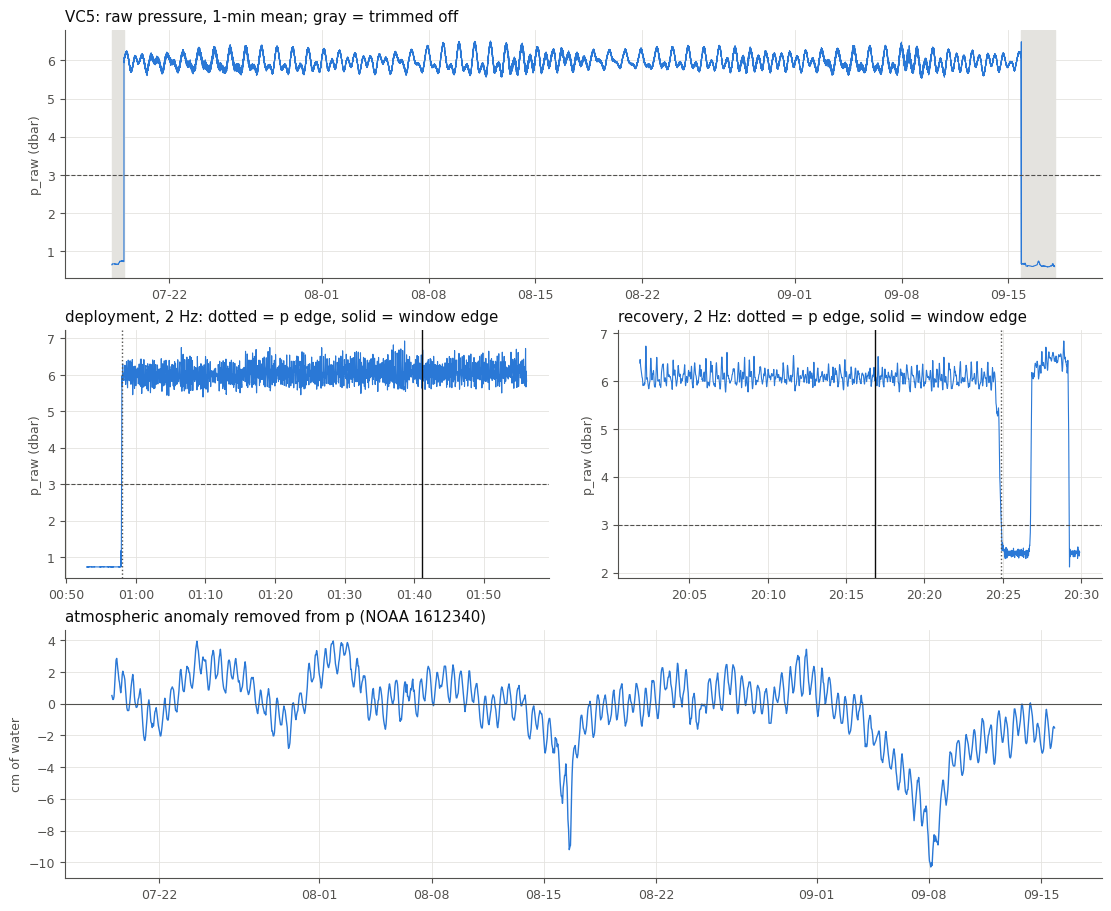

In [9]:
##-----figure: trim window + atmospheric correction-----##
# top row: whole raw record at 1-min means (10.7 M points is too many to draw); gray = cut
p1 = pd.Series(p_raw, index=t).resample("1min").mean()
fig = plt.figure(figsize=(11, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 2)

ax = fig.add_subplot(gs[0, :])
ax.plot(p1.index, p1.values, color=SERIES, lw=0.8)
ax.axvspan(p1.index[0], t_in, color=GRID, zorder=0)
ax.axvspan(t_out, p1.index[-1], color=GRID, zorder=0)
ax.axhline(P_WET, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("p_raw (dbar)")
ax.set_title(f"{sensor_id}: raw pressure, 1-min mean; gray = trimmed off", loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# middle row: 2 Hz zooms around each end. Dotted = pressure edge (p >= 3 dbar),
# solid = final window edge after the handling cut + buffer
zooms = [(t[i_in] - pd.Timedelta(minutes=5), t_in + pd.Timedelta(minutes=15), t[i_in], t_in, "deployment"),
         (t_out - pd.Timedelta(minutes=15), t[i_out] + pd.Timedelta(minutes=5), t[i_out], t_out, "recovery")]
for j, (a, b, tp, te, lab) in enumerate(zooms):
    ax = fig.add_subplot(gs[1, j])
    w = (t > a) & (t < b)
    ax.plot(t[w], p_raw[w], color=SERIES, lw=0.8)
    ax.axhline(P_WET, color=INK2, ls="--", lw=0.8)
    ax.axvline(tp, color=INK2, ls=":", lw=1)
    ax.axvline(te, color=INK, lw=1)
    ax.set_title(f"{lab}, 2 Hz: dotted = p edge, solid = window edge", loc="left", color=INK)
    ax.set_ylabel("p_raw (dbar)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# bottom row: the barometric anomaly removed from p, in cm of water (10-min means)
ax = fig.add_subplot(gs[2, :])
a1 = pd.Series(100 * (patm_k - np.median(patm_k)), index=t[keep]).resample("10min").mean()
ax.plot(a1.index, a1.values, color=SERIES, lw=1)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylabel("cm of water")
ax.set_title("atmospheric anomaly removed from p (NOAA 1612340)", loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

fig.savefig(fig_dir / f"{sensor_id}_trim.png", dpi=150)
plt.show()

#### 2b. Tide-gauge check of the corrected clock (coarse)
Cross-correlate the sensor's tide (1-min mean water level from `p`) with the NOAA CO-OPS 6-min
water level at Honolulu 1612340. A lag near 0 confirms the clock is UTC with no hour-scale or
time-zone error. It **cannot** resolve seconds: the tide is too slow, and Ewa and Honolulu Harbor
differ in tidal phase by minutes anyway. Seconds-level checking needs the co-located Signature 1000
(VC10 only: wave-band p–p cross-correlation, after the ADCP's own -6 s drift correction). That is
pending the ADCP data.

tide lag VC5 vs Honolulu: +0 min (r = 0.9856); tidal amplitude ratio sensor/gauge = 1.029


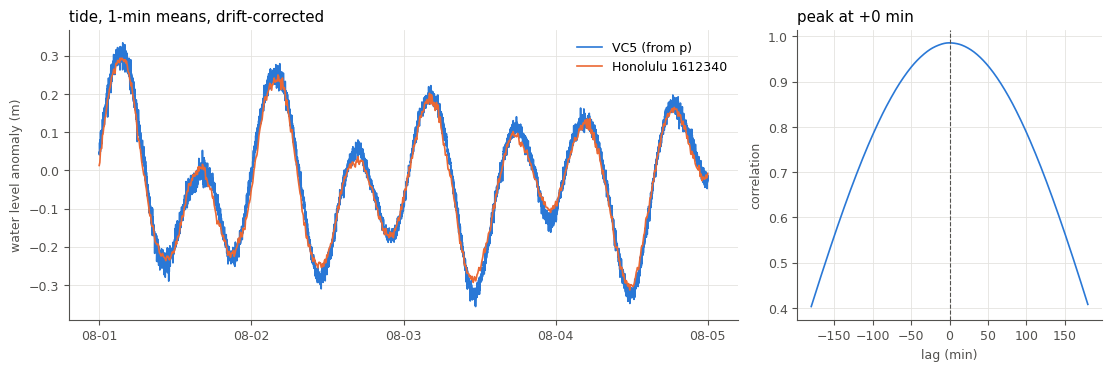

In [10]:
##-----tide-gauge check: coarse clock / time-zone test-----##
# NOAA CO-OPS 1612340 (Honolulu Harbor), 6-min water level relative to MSL, GMT. The API caps
# 6-min requests at 31 days, so fetch in chunks. Cached next to the barometer file.
wl_csv = root / "data" / "metadata" / "noaa_1612340_water_level.csv"
if not wl_csv.exists():
    parts = []
    for a, b in [("20260718", "20260817"), ("20260818", "20260917"), ("20260918", "20260919")]:
        url = ("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=water_level"
               f"&station=1612340&begin_date={a}&end_date={b}&datum=MSL&units=metric"
               "&time_zone=gmt&format=csv&application=4EWA")
        parts.append(pd.read_csv(url, skipinitialspace=True))
    pd.concat(parts).drop_duplicates("Date Time").to_csv(wl_csv, index=False)
wl = pd.read_csv(wl_csv, skipinitialspace=True, parse_dates=["Date Time"]).dropna(subset=["Water Level"])
gauge = wl.set_index("Date Time")["Water Level"]

# water level: hydrostatic p -> m of water (RHO, GRAV from the parameters cell),
# then 1-min means to average out the waves. The gauge's 6-min series is interpolated onto the
# same minutes. Only the tidal variation matters, so both are de-meaned.
eta = pd.Series(out.p.values * 1e4 / (RHO * GRAV), index=out.time.values).resample("1min").mean()
g_i = pd.Series(np.interp(eta.index.values.astype("int64"),
                          gauge.index.values.astype("int64"), gauge.values), index=eta.index)
eta_a, g_a = eta - eta.mean(), g_i - g_i.mean()

# correlation at lags of -3 h to +3 h in 1-min steps. Lag L compares the sensor at t with the gauge at
# t - L. The peak should sit at ~0; a +/-600 min peak would mean a Hawaii-time clock.
lags = np.arange(-180, 181)
r = np.array([eta_a.corr(g_a.shift(L)) for L in lags])
best = lags[np.argmax(r)]
print(f"tide lag {sensor_id} vs Honolulu: {best:+d} min (r = {r.max():.4f}); "
      f"tidal amplitude ratio sensor/gauge = {eta_a.std() / g_a.std():.3f}")
out.attrs["qc_clock_tide_lag_min"] = int(best)

# figure: left = 4-day overlay, right = correlation vs lag
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True,
                        gridspec_kw={"width_ratios": [2.2, 1]})
w = slice("2026-08-01", "2026-08-04")
axs[0].plot(eta_a[w].index, eta_a[w].values, color="#2a78d6", lw=1.2, label=f"{sensor_id} (from p)")
axs[0].plot(g_a[w].index, g_a[w].values, color="#eb6834", lw=1.2, label="Honolulu 1612340")
axs[0].set_ylabel("water level anomaly (m)")
axs[0].set_title("tide, 1-min means, drift-corrected", loc="left")
axs[0].legend(frameon=False)
axs[0].xaxis.set_major_locator(mdates.DayLocator())
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axs[1].plot(lags, r, color="#2a78d6", lw=1.2)
axs[1].axvline(best, color="#52514e", ls="--", lw=0.8)
axs[1].set_xlabel("lag (min)")
axs[1].set_ylabel("correlation")
axs[1].set_title(f"peak at {best:+d} min", loc="left")
fig.savefig(fig_dir / f"{sensor_id}_clock_tide.png", dpi=150)
plt.show()

### 3. Beam Quality masks
Thresholds follow Elgar, Raubenheimer & Guza (2001, *J. Atmos. Oceanic Technol.* 18, 1735–1746) and
Elgar, Raubenheimer & Guza (2005, *Meas. Sci. Technol.* 16, 1889–1893, "Quality control of acoustic
Doppler velocimeter data in the surfzone"), both in `lit/`. These replace the lab's 70 % correlation cut.
 - **Correlation:** threshold `0.3 + 0.4·√(fs/25)`. This is SonTek's recommended 0.7 at 25 Hz, relaxed because
   statistical error goes as 1/√(pulses per sample). The Vector pings at 100–250 Hz internally and averages
   down to the output rate, so the √fs argument applies: **41.3 % at 2 Hz**.
 - **SNR:** Elgar et al. (2005) use **SNR < 8** for NorTek Vectors as a whole-run rule: a run is discarded if
   more than 0.81 % of its samples (25·fs per 3072 s) are low SNR. The rule exists to catch sensors out of
   the water or blocked.
 - Gate per channel, not per row: pressure and velocity fail independently (lab channel decoupling).
 - Report the % flagged per sensor and per hour, and plot it against time and Hs.


#### 3a. Correlation gate + SNR flag

Input is `out` from section 2 (clock-corrected, trimmed, atmosphere removed).
1. **Correlation gate (applied).** A velocity sample is marked bad unless **all three** beams have
   `corr >= CORR_MIN`, with `CORR_MIN = 100·(0.3 + 0.4·√(fs/25))` (41.3 % at 2 Hz). The gate is per sample,
   not per component: u, v and w each combine all three beams, so one bad beam corrupts all three.
   Pressure and temperature are not touched. Section 4 replaces the bad samples (Elgar's method).
   - **Supporting check** (2026-10-03, ungated raw velocities, 3-point residual noise vs. min correlation):
     the noise rises smoothly with no knee. It is ~1.5–1.8× the corr ≥ 90 % level at 65–70 %, and
     ~2–2.7× (6–7 cm/s) at 40–45 %. Going from 70 % to 41.3 % cuts the flagged fraction from 17.7 → 3.1 % (VA10),
     9.0 → 3.9 % (VD5), 2.4 → 0.1 % (VC5).
2. **SNR (hourly flag, not applied).** `SNR = 0.43 dB/count × (amp − noise floor)`, with the noise floor per beam
   taken as the median pre-deployment in-air amplitude. This matches the noise amplitude the Vector writes in
   its .VEC velocity headers to within 1–2 counts, so the scale is Nortek's and Elgar's 8 dB transfers.
   `vel_low_snr` marks samples with any beam < `SNR_MIN`. Section 4 stores Elgar's run rule per hour as
   `seg_snr_ok` (≤ 0.81 % low SNR). **It is not a gate here.** These sensors are always 4–10 m deep, and
   low SNR comes from clear water (few scatterers). Samples with SNR < 8 but corr ≥ 70 % are only
   ~1.4–1.9× noisier (~3 cm/s). Applied as a gate, it would drop 207 of 1392 hours on VC10 and 432 of 1391 on VE10,
   although both pass the Z-test.
3. **Diagnostics.** % flagged per hour against time and against `Hs_p`; daily median correlation
   and amplitude per beam (a steady decline = biofouling or burial); correlation histograms.
   `Hs_p = 4 × std` of bed pressure after a 5-min high-pass, in m of water. It is **not**
   corrected for depth attenuation, so it underestimates Hs. It is only used
   to see whether the flag rate tracks wave energy.
4. Nothing is saved here; everything goes into `{sensor}_QC.nc` at the end.


In [11]:
##-----beam quality: correlation gate (Elgar et al. 2001/2005) + SNR flag-----##
corr = out["corr"].values                 # (beam, time), %
amp  = out["amp"].values.astype(float)    # (beam, time), counts
fs   = float(ds.attrs["fs"])

# Elgar et al. (2001, 2005): 0.3 + 0.4 sqrt(fs/25), i.e. SonTek's 0.7 at 25 Hz relaxed as sqrt(fs)
CORR_MIN = 100 * (CORR_A + CORR_B * np.sqrt(fs / CORR_REF_FS))

# correlation, per beam, then per sample: all three beams must pass
corr_ok_beam = corr >= CORR_MIN
vel_ok = corr_ok_beam.all(axis=0)

# amplitude -> SNR. Noise floor per beam = median in-air amplitude before deployment
# (`pre` from section 2: p_raw < P_AIR, > 5 min before the splash), where no echo comes back.
noise = np.median(ds["amp"].values[:, pre], axis=1)
snr = AMP_DB_PER_COUNT * (amp - noise[:, None])
low_snr = (snr < SNR_MIN).any(axis=0)

bad = ~vel_ok | (low_snr if APPLY_SNR else False)

# new dataset: u, v, w NaN where bad (section 4 replaces them); everything else as in `out`.
# `out` itself is left untouched: section 4 needs its recorded values for the running mean.
bq = out.copy()
keep_da = xr.DataArray(~bad, dims="time")
for c in ["u", "v", "w"]:
    bq[c] = out[c].where(keep_da)
    bq[c].attrs = dict(out[c].attrs, beam_qc=f"bad where min beam corr < {CORR_MIN:.1f} % (Elgar et al. 2001/2005)"
                       + (f" or any beam SNR < {SNR_MIN} dB" if APPLY_SNR else ""))
bq["vel_corr_ok"] = xr.DataArray(vel_ok, dims="time",
    attrs={"long_name": f"all three beam correlations >= {CORR_MIN:.1f} % (0.3 + 0.4 sqrt(fs/25), Elgar et al. 2005)"})
bq["vel_low_snr"] = xr.DataArray(low_snr, dims="time",
    attrs={"long_name": f"any beam SNR < {SNR_MIN} dB", "applied": str(APPLY_SNR)})
bq.attrs.update({
    "qc_beam_corr_rule": f"Elgar et al. 2001/2005: {CORR_A} + {CORR_B} sqrt(fs/{CORR_REF_FS:g})",
    "qc_beam_corr_min_pct": float(CORR_MIN),
    "qc_beam_snr_min_db": SNR_MIN,
    "qc_beam_snr_applied": str(APPLY_SNR),
    "qc_beam_amp_noise_floor_counts": ", ".join(f"{x:.0f}" for x in noise),
    "qc_beam_vel_flagged_pct": float(100 * bad.mean()),
})

# runs of consecutive flagged samples (section 4 replaces them by length)
g0, g1 = runs(bad)
glen = g1 - g0 + 1

n = bad.size
print(f"{sensor_id}: CORR_MIN = 0.3 + 0.4 sqrt({fs:g}/25) = {CORR_MIN:.1f} %")
print(f"  velocity flagged in {100 * bad.mean():.2f} % of {n:,} in-water samples "
      f"(at the old 70 %: {100 * (corr < 70).any(axis=0).mean():.2f} %)")
for b in range(3):
    print(f"  beam {b + 1}: corr < {CORR_MIN:.1f} % in {100 * (~corr_ok_beam[b]).mean():.2f} %, "
          f"median corr {np.median(corr[b]):.0f} %, noise floor {noise[b]:.0f} counts, "
          f"median SNR {np.median(snr[b]):.1f} dB")
print(f"  low SNR (< {SNR_MIN:g} dB, any beam): {100 * low_snr.mean():.2f} % "
      f"({100 * (low_snr & vel_ok).mean():.2f} % NOT already caught by correlation) -> "
      f"{'applied' if APPLY_SNR else 'hourly flag only'}")
if glen.size:
    print(f"  flagged runs: {glen.size:,}; median {np.median(glen):.0f} samples, "
          f"{100 * (glen <= ELGAR_INTERP_MAX_S * fs).mean():.0f} % are <= {ELGAR_INTERP_MAX_S:g} s, longest {glen.max():,} "
          f"samples ({glen.max() / fs / 60:.1f} min)")


VC5: CORR_MIN = 0.3 + 0.4 sqrt(2/25) = 41.3 %


  velocity flagged in 0.10 % of 10,156,279 in-water samples (at the old 70 %: 2.36 %)


  beam 1: corr < 41.3 % in 0.04 %, median corr 97 %, noise floor 42 counts, median SNR 29.7 dB
  beam 2: corr < 41.3 % in 0.01 %, median corr 96 %, noise floor 42 counts, median SNR 28.8 dB


  beam 3: corr < 41.3 % in 0.08 %, median corr 95 %, noise floor 43 counts, median SNR 26.2 dB
  low SNR (< 8 dB, any beam): 3.56 % (3.46 % NOT already caught by correlation) -> hourly flag only
  flagged runs: 7,483; median 1 samples, 92 % are <= 1 s, longest 16 samples (0.1 min)


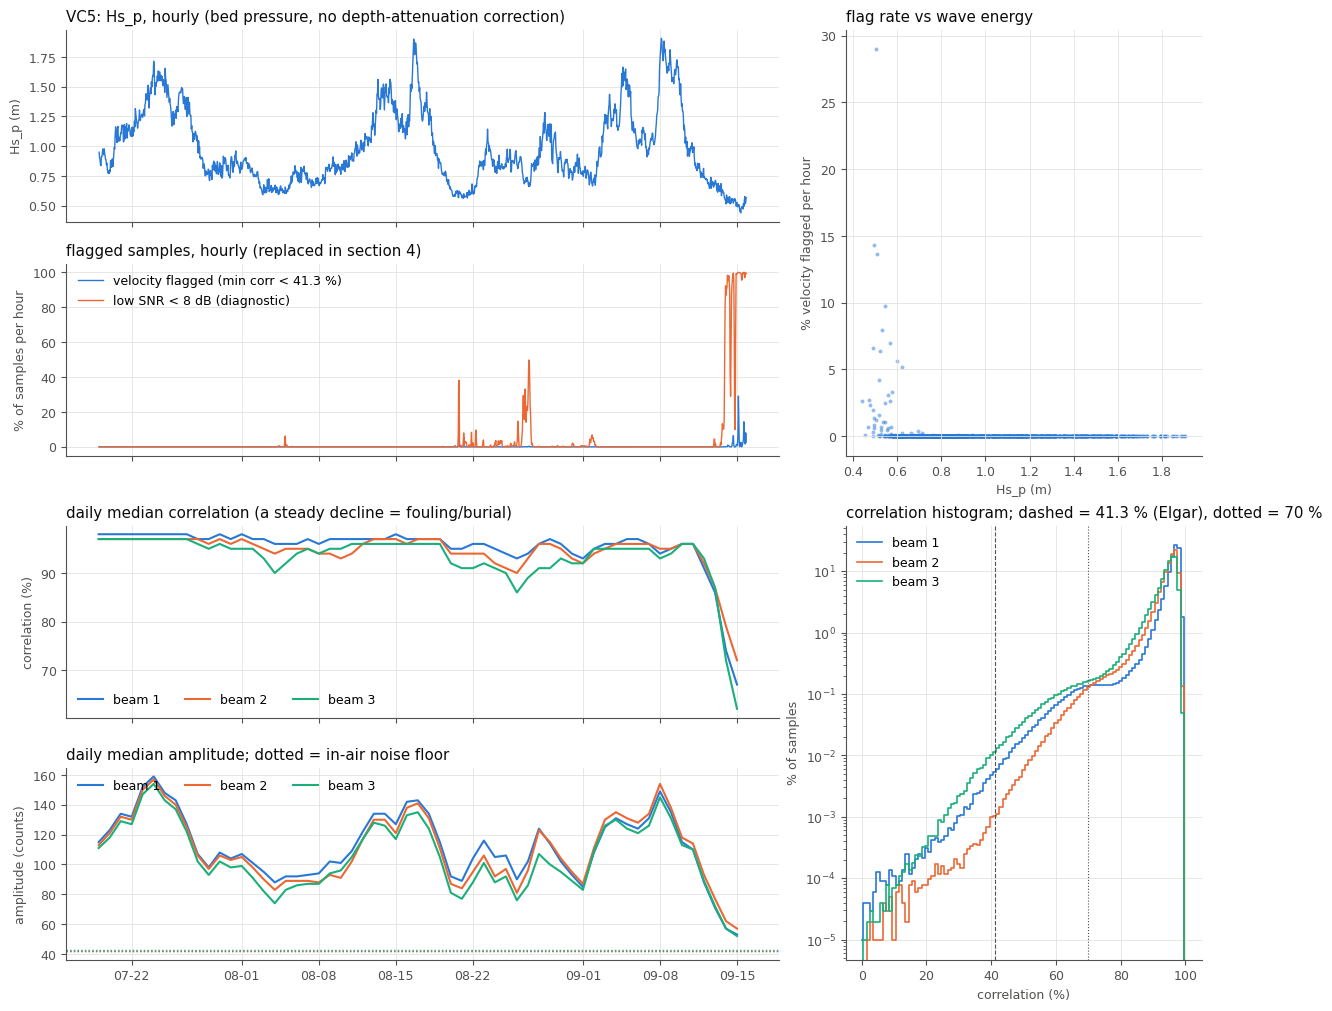

hourly flag rate: median 0.00 %, max 29.0 % (2026-09-15 03:00:00); corr with Hs_p r = -0.14


In [12]:
##-----figure: beam quality over the deployment-----##
tq = pd.DatetimeIndex(bq.time.values)
fs = float(ds.attrs["fs"])

# Hs_p: 4 * std of bed pressure after a 5-min high-pass (removes tide), per hour, m of water.
# NOT corrected for depth attenuation: a wave-energy proxy only.
p_s = pd.Series(out.p.values.astype(float), index=tq)
p_hp = p_s - p_s.rolling(int(300 * fs), center=True, min_periods=int(60 * fs)).mean()
hs_p = 4 * p_hp.resample("1h").std() * 1e4 / (RHO * GRAV)

flag_h = 100 * pd.Series(bad, index=tq).resample("1h").mean()
snr_h  = 100 * pd.Series(low_snr, index=tq).resample("1h").mean()
corr_d = pd.DataFrame(corr.T, index=tq).resample("1D").median()
amp_d  = pd.DataFrame(amp.T, index=tq).resample("1D").median()

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(4, 3)

# left column: time series, shared x
ax0 = fig.add_subplot(gs[0, :2])
ax0.plot(hs_p.index, hs_p.values, color=SERIES, lw=1)
ax0.set_ylabel("Hs_p (m)")
ax0.set_title(f"{sensor_id}: Hs_p, hourly (bed pressure, no depth-attenuation correction)",
              loc="left", color=INK)

ax1 = fig.add_subplot(gs[1, :2], sharex=ax0)
ax1.plot(flag_h.index, flag_h.values, color=BEAM_COLORS[0], lw=1,
         label=f"velocity flagged (min corr < {CORR_MIN:.1f} %)")
ax1.plot(snr_h.index, snr_h.values, color=BEAM_COLORS[1], lw=1,
         label=f"low SNR < {SNR_MIN:g} dB ({'applied' if APPLY_SNR else 'diagnostic'})")
ax1.set_ylabel("% of samples per hour")
ax1.set_title("flagged samples, hourly (replaced in section 4)", loc="left", color=INK)
ax1.legend(frameon=False, loc="upper left")

ax2 = fig.add_subplot(gs[2, :2], sharex=ax0)
for b in range(3):
    ax2.plot(corr_d.index, corr_d[b].values, color=BEAM_COLORS[b], lw=1.5, label=f"beam {b + 1}")
ax2.set_ylabel("correlation (%)")
ax2.set_title("daily median correlation (a steady decline = fouling/burial)", loc="left", color=INK)
ax2.legend(frameon=False, loc="lower left", ncol=3)

ax3 = fig.add_subplot(gs[3, :2], sharex=ax0)
for b in range(3):
    ax3.plot(amp_d.index, amp_d[b].values, color=BEAM_COLORS[b], lw=1.5, label=f"beam {b + 1}")
    ax3.axhline(noise[b], color=BEAM_COLORS[b], ls=":", lw=1)
ax3.set_ylabel("amplitude (counts)")
ax3.set_title("daily median amplitude; dotted = in-air noise floor", loc="left", color=INK)
ax3.legend(frameon=False, loc="upper left", ncol=3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
for a in (ax0, ax1, ax2):
    a.tick_params(labelbottom=False)

# right column: flag rate vs wave energy, and correlation histograms
ax4 = fig.add_subplot(gs[:2, 2])
both = pd.concat([hs_p.rename("hs"), flag_h.rename("f")], axis=1).dropna()
ax4.scatter(both.hs, both.f, s=8, color=SERIES, alpha=0.5, lw=0)
ax4.set_xlabel("Hs_p (m)")
ax4.set_ylabel("% velocity flagged per hour")
ax4.set_title("flag rate vs wave energy", loc="left", color=INK)

ax5 = fig.add_subplot(gs[2:, 2])
bins = np.arange(0, 102)
for b in range(3):
    h = np.bincount(corr[b], minlength=101)[:101]
    ax5.step(bins[:-1], 100 * h / h.sum(), where="mid", color=BEAM_COLORS[b], lw=1.2,
             label=f"beam {b + 1}")
ax5.axvline(CORR_MIN, color=INK2, ls="--", lw=0.8)
ax5.axvline(70, color=INK2, ls=":", lw=0.8)
ax5.set_yscale("log")
ax5.set_xlabel("correlation (%)")
ax5.set_ylabel("% of samples")
ax5.set_title(f"correlation histogram; dashed = {CORR_MIN:.1f} % (Elgar), dotted = 70 %", loc="left", color=INK)
ax5.legend(frameon=False, loc="upper left")

fig.savefig(fig_dir / f"{sensor_id}_beam.png", dpi=150)
plt.show()
print(f"hourly flag rate: median {flag_h.median():.2f} %, max {flag_h.max():.1f} % "
      f"({flag_h.idxmax()}); corr with Hs_p r = {both.hs.corr(both.f):.2f}")

### 4. Elgar replacement of low-correlation samples + hourly segment flags
Despiking was tested here and removed. Goring & Nikora (2002) phase-space thresholding, Mori et al. (2007), and a
universal threshold on a wave-free residual all flagged real orbital-velocity crests at 2 Hz in waves (on VC5,
~45 % of u-triggered flags sat on crests at every threshold). So the only velocity mask is the beam
correlation gate (section 3).

What this section does (Elgar, Raubenheimer & Guza 2001, 2005):
1. **Runs ≤ `ELGAR_INTERP_MAX_S` (1 s)** of samples below the correlation threshold are replaced by values
   **linearly interpolated** between the good samples before and after. At 2 Hz this is runs of 1–2 samples.
   Elgar says "< 1 s"; a 2-sample run is exactly 1 s and is interpolated too.
2. **Longer runs** are replaced by a **1-s running mean of the recorded (incoherent) values themselves**, as in the
   paper. At 2 Hz a centred 1-s window is 3 taps with weights [¼, ½, ¼]; at the record ends it is renormalized.
   A short run touching the start or end of the record has no neighbour to interpolate from, so it gets the
   running mean too.
   *Caveat:* at 2 Hz a 1-s mean smooths much less than at Elgar's 16 Hz. Long incoherent runs keep most of
   their noise (~6–7 cm/s per sample near the threshold). They are unbiased, but they are still noisy.
3. **Where the replaced values are:** `vel_qc_flag` (int8, per sample): **0** = good (measured),
   **1** = linearly interpolated (run ≤ 1 s), **2** = 1-s running mean (run > 1 s). No velocity NaNs remain.
   The unreplaced values can be recovered from `{S}_raw.nc`.
4. **Per-hour table** (the lab's 1-h segments, aligned to HH:00): % interpolated, % running mean, % low SNR.
   - `seg_runmean_ok` = running mean ≤ `RUNMEAN_MAX_FRAC` (10 %). Elgar does not reject runs by the low-correlation
     count, but hours dominated by long incoherent stretches are worth marking.
   - `seg_ok` (the final hourly flag) is set in section 6: `seg_runmean_ok` AND 0.5 < z² < 2.0.
   - `seg_snr_ok` = Elgar's SNR run rule (≤ 0.81 % of samples with any beam < 8 dB). A flag only (see section 3).


In [13]:
##-----Elgar replacement of low-correlation samples + hourly segment flags-----##
comps = ["u", "v", "w"]
tq = pd.DatetimeIndex(bq.time.values)
seg_n = int(3600 * fs)                                   # samples per 1-h segment
hcode = np.asarray((tq - tq[0].floor("1h")) // pd.Timedelta(hours=1))   # clock-hour index per sample
n = tq.size

def expand(starts, lengths):
    """indices covered by runs (start, length)"""
    return np.repeat(starts, lengths) + (np.arange(lengths.sum()) - np.repeat(np.cumsum(lengths) - lengths, lengths))

# run classes (shared by u, v, w: the gate is per sample)
n_lin = int(round(ELGAR_INTERP_MAX_S * fs))              # longest run (samples) that is interpolated: 2 at 2 Hz
has_nb = (g0 > 0) & (g1 < n - 1)                         # a good sample exists on both sides
short = (glen <= n_lin) & has_nb
i_lin = expand(g0[short], glen[short])
i_rm  = expand(g0[~short], glen[~short])
vel_qc_flag = np.zeros(n, np.int8)
vel_qc_flag[i_lin] = 1
vel_qc_flag[i_rm]  = 2

# 1-s running mean: centred window spanning ELGAR_RUNMEAN_S, half weights on the end taps
# (fs = 2 Hz -> [0.25, 0.5, 0.25]); renormalized where it runs off the record or over a NaN
n_w = int(round(ELGAR_RUNMEAN_S * fs))
w_rm = np.ones(n_w + 1); w_rm[[0, -1]] = 0.5; w_rm /= w_rm.sum()

def elgar_replace(raw):
    """raw = recorded velocity (before the beam mask). Short runs: linear interpolation between good samples;
    long runs: running mean of the recorded values themselves (Elgar et al. 2001, 2005)."""
    x = raw.astype(float).copy()
    good = (vel_qc_flag == 0) & np.isfinite(x)
    ig = np.flatnonzero(good)
    x[i_lin] = np.interp(i_lin, ig, x[ig])
    fin = np.isfinite(raw)
    rm = (np.convolve(np.where(fin, raw, 0.0), w_rm, "same")
          / np.convolve(fin.astype(float), w_rm, "same"))
    x[i_rm] = rm[i_rm]
    return x

fl = bq.copy()
for c in comps:
    fl[c] = xr.DataArray(elgar_replace(out[c].values).astype("float32"), dims="time",
                         attrs=dict(bq[c].attrs, replaced=(
                             "low-corr runs <= 1 s linearly interpolated, longer runs = 1-s running mean of the "
                             "recorded values (Elgar et al. 2001, 2005); see vel_qc_flag")))
fl["vel_qc_flag"] = xr.DataArray(vel_qc_flag, dims="time", attrs={
    "long_name": "velocity replacement flag (Elgar et al. 2001, 2005)",
    "flag_values": np.array([0, 1, 2], np.int8),
    "flag_meanings": "good linear_interp_run_le_1s running_mean_1s_run_gt_1s",
    "comment": f"applies to u, v, w together; bad = min beam corr < {CORR_MIN:.1f} %"})

# per-hour table (the lab's 1-h spectral segments, aligned to HH:00)
seg = (pd.DataFrame({"interp": vel_qc_flag == 1, "runmean": vel_qc_flag == 2, "snr_low": low_snr}, index=tq)
         .resample("1h").mean() * 100)
seg["ok"] = seg["runmean"] <= 100 * RUNMEAN_MAX_FRAC
seg["snr_ok"] = seg["snr_low"] <= 100 * SNR_RUN_FRAC
fl = fl.assign_coords(hour=seg.index.values)
fl["seg_interp_pct"]  = ("hour", seg["interp"].values.astype("float32"),
                         {"long_name": "% velocity linearly interpolated (vel_qc_flag 1)"})
fl["seg_runmean_pct"] = ("hour", seg["runmean"].values.astype("float32"),
                         {"long_name": "% velocity replaced by 1-s running mean (vel_qc_flag 2)"})
fl["seg_runmean_ok"] = ("hour", seg["ok"].values,
                         {"long_name": f"1-h segment has <= {100 * RUNMEAN_MAX_FRAC:g} % running-mean velocity"})
fl["seg_snr_low_pct"] = ("hour", seg["snr_low"].values.astype("float32"),
                         {"long_name": f"% samples with any beam SNR < {SNR_MIN:g} dB"})
fl["seg_snr_ok"]      = ("hour", seg["snr_ok"].values,
                         {"long_name": f"<= {100 * SNR_RUN_FRAC:g} % samples with SNR < {SNR_MIN:g} dB",
                          "comment": "Elgar et al. 2005 run-rejection rule; diagnostic, NOT applied to seg_ok"})
fl.attrs.update({
    "qc_despike": "none (tested; removed real wave crests at 2 Hz)",
    "qc_replace_rule": (f"Elgar et al. 2001/2005: low-corr runs <= {ELGAR_INTERP_MAX_S:g} s linear interpolation; "
                        f"longer runs {ELGAR_RUNMEAN_S:g}-s running mean (weights {np.round(w_rm, 3).tolist()}) "
                        "of the recorded values"),
    "qc_replace_interp_pct": float(100 * (vel_qc_flag == 1).mean()),
    "qc_replace_runmean_pct": float(100 * (vel_qc_flag == 2).mean()),
    "qc_seg_runmean_max_frac": RUNMEAN_MAX_FRAC,
    "qc_seg_runmean_ok_pct": float(100 * seg["ok"].mean()),
    "qc_seg_snr_run_frac": SNR_RUN_FRAC,
    "qc_seg_snr_fail_pct": float(100 * (~seg["snr_ok"]).mean()),
})

assert not np.isnan(fl["u"].values).any(), "velocity NaN left after replacement"
L_rm = glen[~short]
print(f"{sensor_id}: replaced {100 * (vel_qc_flag > 0).mean():.2f} % of samples "
      f"(= flagged {100 * bad.mean():.2f} %)")
print(f"  linear interp (runs <= {ELGAR_INTERP_MAX_S:g} s): {short.sum():,} runs, {i_lin.size:,} samples "
      f"({100 * (vel_qc_flag == 1).mean():.2f} %)")
print(f"  1-s running mean (runs > {ELGAR_INTERP_MAX_S:g} s): {(~short).sum():,} runs, {i_rm.size:,} samples "
      f"({100 * (vel_qc_flag == 2).mean():.2f} %); longest {L_rm.max() if L_rm.size else 0:,} samples")
print(f"  1-h segments: {seg['ok'].sum()} of {len(seg)} pass running mean <= {100 * RUNMEAN_MAX_FRAC:g} % (seg_runmean_ok) "
      f"(failing: {', '.join(f'{h:%m-%d %H}h' for h in seg.index[~seg['ok']][:8])}"
      f"{' ...' if (~seg['ok']).sum() > 8 else ''})")
print(f"  SNR run rule (Elgar 2005, flag only): {(~seg['snr_ok']).sum()} of {len(seg)} hours have > "
      f"{100 * SNR_RUN_FRAC:g} % samples with SNR < {SNR_MIN:g} dB")


VC5: replaced 0.10 % of samples (= flagged 0.10 %)
  linear interp (runs <= 1 s): 6,851 runs, 7,993 samples (0.08 %)
  1-s running mean (runs > 1 s): 632 runs, 2,428 samples (0.02 %); longest 16 samples
  1-h segments: 1411 of 1412 pass running mean <= 10 % (seg_runmean_ok) (failing: 09-15 03h)
  SNR run rule (Elgar 2005, flag only): 151 of 1412 hours have > 0.81 % samples with SNR < 8 dB


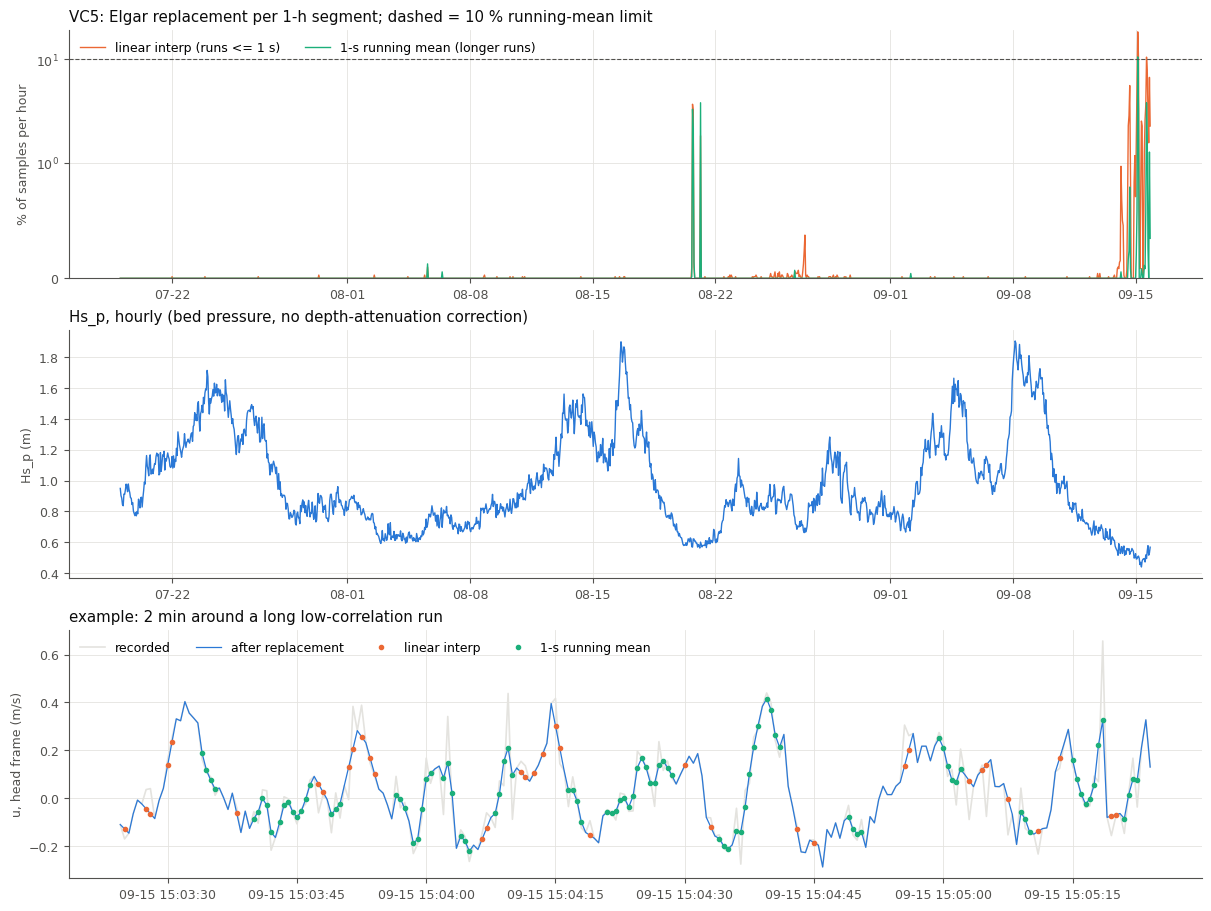

In [14]:
##-----figure: Elgar replacement per hour + example of where values were replaced-----##
fig, axs = plt.subplots(3, 1, figsize=(12, 9), constrained_layout=True)
ax = axs[0]
ax.plot(seg.index, seg["interp"].values, color=BEAM_COLORS[1], lw=1,
        label=f"linear interp (runs <= {ELGAR_INTERP_MAX_S:g} s)")
ax.plot(seg.index, seg["runmean"].values, color=BEAM_COLORS[2], lw=1, label="1-s running mean (longer runs)")
ax.axhline(100 * RUNMEAN_MAX_FRAC, color=INK2, ls="--", lw=0.8)
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(bottom=0)
ax.set_ylabel("% of samples per hour")
ax.set_title(f"{sensor_id}: Elgar replacement per 1-h segment; dashed = {100 * RUNMEAN_MAX_FRAC:g} % running-mean limit",
             loc="left", color=INK)
ax.legend(frameon=False, loc="upper left", ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax = axs[1]
ax.plot(hs_p.index, hs_p.values, color=SERIES, lw=1)
ax.set_ylabel("Hs_p (m)")
ax.set_title("Hs_p, hourly (bed pressure, no depth-attenuation correction)", loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# zoom: 2 min around the longest running-mean run that fits in the window (else the longest run), u (head frame)
ax = axs[2]
cand = np.flatnonzero(~short & (glen <= 200))
k = cand[np.argmax(glen[cand])] if cand.size else (np.argmax(glen) if glen.size else None)
if k is not None:
    mid = (g0[k] + g1[k]) // 2
    sl = slice(max(mid - int(60 * fs), 0), min(mid + int(60 * fs), n))
    tt = tq[sl]
    ax.plot(tt, out["u"].values[sl], color=GRID, lw=1.2, label="recorded")
    ax.plot(tt, fl["u"].values[sl], color=SERIES, lw=0.9, label="after replacement")
    for v, col, lab in [(1, BEAM_COLORS[1], "linear interp"), (2, BEAM_COLORS[2], "1-s running mean")]:
        m = vel_qc_flag[sl] == v
        ax.plot(tt[m], fl["u"].values[sl][m], "o", ms=3, color=col, label=lab)
    ax.set_ylabel("u, head frame (m/s)")
    ax.set_title("example: 2 min around a long low-correlation run", loc="left", color=INK)
    ax.legend(frameon=False, loc="upper left", ncol=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M:%S"))
fig.savefig(fig_dir / f"{sensor_id}_fill.png", dpi=150)
plt.show()


### 5. Rotation to earth/shore-normal
- The internal compass and tilt sensor are in the canister, not the probe head (Nortek Comprehensive
  Manual N3015-030: "The tilt sensor and compass are both located in the housing"; "XYZ and Beam
  velocity data are gathered with respect to the probe head only"). These are cable heads, so the
  internal heading/pitch/roll say nothing about the head and are not used here.
- Rotate head XYZ to earth with the KVH magnetic heading (sensor_notes.csv, the bearing of the +X /
  red arm) + declination, head assumed vertical. Then rotate to shore-normal coordinates, using the
  shore-normal of the sensor's transect (sensor_notes.csv: shoreline bearing W→E minus 90°).
 - Verify the heading physically. This is how the lab caught its 180° errors:
   a. p–u co-spectrum phase ≈ 0 and sign consistent with onshore-propagating swell (south swell at Ewa) [lit/: Elgar & Guza 1985; Sheremet et al. 2002].
   b. The mean-current principal axis should be ~alongshore. The lab ranks this above wave-direction estimators (PIPELINE_NOTES.md, "Deriving a shore-normal"). Use
      dolfyn.calc_principal_heading. Check anisotropy: ≈1 means the axis is meaningless.
   c. VC10 vs the co-located Signature 1000 ADCP: mean current and wave
      direction should agree after rotation.
   d. Mean wave direction should be consistent across the array (no one sensor 90°/180° off).

#### 5a. KVH heading + declination, then shore-normal

Input is `fl` from section 4 (instrument/head frame, beam-masked, short gaps filled).
1. **Head orientation (constant).** +X (red arm) points at `KVH + DECLINATION_DEG` true; the head is
   level and points up, so Nortek XYZ has +Z down (`HEAD_UP`: roll = 180°). The matrix comes from
   dolfyn's `euler2orient`, so the heading/roll conventions are dolfyn's. It is applied as one 3×3
   matrix rather than through `dolfyn.rotate2`: rotate2 rebuilds a (3, 3, time) orientmat from the
   *canister's* heading/pitch/roll (~0.7 GB for 10 M samples) and flips on the canister's
   `orientation_down` bit, neither of which describes the head.
2. **Declination** is folded into the heading (the same z-rotation dolfyn's `set_declination` does).
3. **Shore-normal:** +u onshore toward `SHORE_NORMAL_DEG`, +v 90° counter-clockwise of that
   (alongshore, toward `SHORE_NORMAL_DEG − 90`), +w up. Right-handed, unlike the lab's left-handed
   +x West/+y North buoy frame. `u_east`/`v_north` are kept too.

**Checks** (hourly, gap-free hours, 0.05–0.3 Hz):
- *Vertical sign.* Under a wave crest passing overhead, w leads p by 90°, so earth-frame w should be
  in phase with dp/dt (coherence ≈ +1). A negative value means +z is down (`HEAD_UP` wrong).
- *Heading (check a).* Horizontal velocity in phase with p points the way the waves travel, so
  `atan2(C_pE, C_pN)` is the direction of travel. It must be onshore (roughly `SHORE_NORMAL_DEG`), not
  180° off.
- *Shore-normal (check b).* Mean-current principal axis (dolfyn `calc_principal_heading` on 10-min
  means) with its anisotropy. Its normal, on the onshore side, is one shore-normal estimate; the
  energy-weighted wave direction is another. Neither replaces `SHORE_NORMAL_DEG` automatically.
  Checks c and d need the other sensors and the Signature, so they wait for the batch run.

In [15]:
##-----rotation: head XYZ -> earth (true ENU) -> shore-normal-----##
from dolfyn.rotate.base import euler2orient
from dolfyn.rotate.api import calc_principal_heading

# KVH heading = magnetic bearing of the probe's +X (red) arm at deployment. Re-read from
# sensor_notes.csv here, so edits to the CSV apply without rebuilding the .nc files.
notes = pd.read_csv(root / "data" / "metadata" / "sensor_notes.csv", dtype=str, skipinitialspace=True)
notes.columns = notes.columns.str.strip()
row = notes[notes["Processed Data Sensor Name (.nc file)"].str.strip() == sensor_id].iloc[0]
heading_mag  = float(row["Magnetic Heading (KVH)"])
heading_true = (heading_mag + DECLINATION_DEG) % 360        # true bearing of +X
# shore-normal of this sensor's transect: the shoreline bearing (W -> E, measured in Google Earth) - 90
SHORE_NORMAL_DEG = (float(row["Shore Normal Onshore (deg true)"]) if SHORE_NORMAL_OVERRIDE is None
                    else float(SHORE_NORMAL_OVERRIDE))

# Orientation of the HEAD, constant over the record: +X at heading_true, level (head assumed
# vertical, no head tilt measurement exists), roll 180 deg when the head points up. dolfyn's
# euler2orient gives earth -> inst; inst -> earth is its transpose.
omat = np.asarray(euler2orient(heading_true, 0.0, 180.0 if HEAD_UP else 0.0), dtype=float)
R_ie = omat.T

X = np.vstack([fl[c].values.astype(float) for c in comps])  # (3, time), head XYZ
E, N, Up = R_ie @ X                                           # true east, north, up

# shore-normal: +x onshore (bearing SHORE_NORMAL_DEG), +y 90 deg counter-clockwise of +x, +z up
sn = np.radians(SHORE_NORMAL_DEG)
u_sn = E * np.sin(sn) + N * np.cos(sn)
v_sn = -E * np.cos(sn) + N * np.sin(sn)

rot = fl.copy()
for c, arr in zip(comps, X):
    rot[f"{c}_inst"] = ("time", arr.astype("float32"), {**fl[c].attrs, "coord_sys": "inst (head XYZ)"})
for name, arr, ln in [("u_east", E, "eastward velocity (true)"), ("v_north", N, "northward velocity (true)"),
                      ("u", u_sn, f"cross-shore velocity, + onshore toward {SHORE_NORMAL_DEG:g} deg true"),
                      ("v", v_sn, f"alongshore velocity, + toward {(SHORE_NORMAL_DEG - 90) % 360:g} deg true"),
                      ("w", Up, "vertical velocity, + up")]:
    rot[name] = ("time", arr.astype("float32"), {"units": "m s-1", "long_name": ln})
rot.attrs["transect"] = row["Transect"].strip()
rot.attrs["coord_sys"] = "shore-normal (u onshore, v alongshore, w up); u_east/v_north true ENU"

print(f"{sensor_id}: KVH {heading_mag:.1f} deg mag + declination {DECLINATION_DEG:+.2f} = +X at {heading_true:.2f} deg true; "
      f"head {'up (roll 180)' if HEAD_UP else 'down'}; shore-normal (onshore) {SHORE_NORMAL_DEG:g} deg true")
print("  inst -> earth matrix (rows E, N, U; columns X, Y, Z):")
print(np.array2string(R_ie, precision=4, suppress_small=True))

VC5: KVH 341.8 deg mag + declination +9.26 = +X at 351.06 deg true; head up (roll 180); shore-normal (onshore) 350 deg true
  inst -> earth matrix (rows E, N, U; columns X, Y, Z):
[[-0.1554  0.9879  0.    ]
 [ 0.9879  0.1554  0.    ]
 [ 0.      0.     -1.    ]]


VC5: 1407 gap-free hours
  1. w vs dp/dt coherence: median +0.91, 100 % of hours > 0  (expect ~ +1 if +z is up)
  2. wave direction of travel: energy-weighted mean 347.0 deg true, hourly 5-95 % 340-353  (expect onshore, ~350)
     wave principal axis: median 166.7 deg (anisotropy 3.59)
  3. mean-current principal axis (10-min means, whole record): 48.3 deg, anisotropy 1.96; daily axis median 53.5 (anisotropy 3.53)
     normal to that axis, onshore side: 318.3 deg true
  mean current: E -0.89, N -4.32 cm/s -> toward 192 deg true; cross-shore -4.10, alongshore +1.63 cm/s
  shore-normal candidates (onshore, deg true): SHORE_NORMAL_DEG 350 | waves 347.0 | current-axis normal 318.3


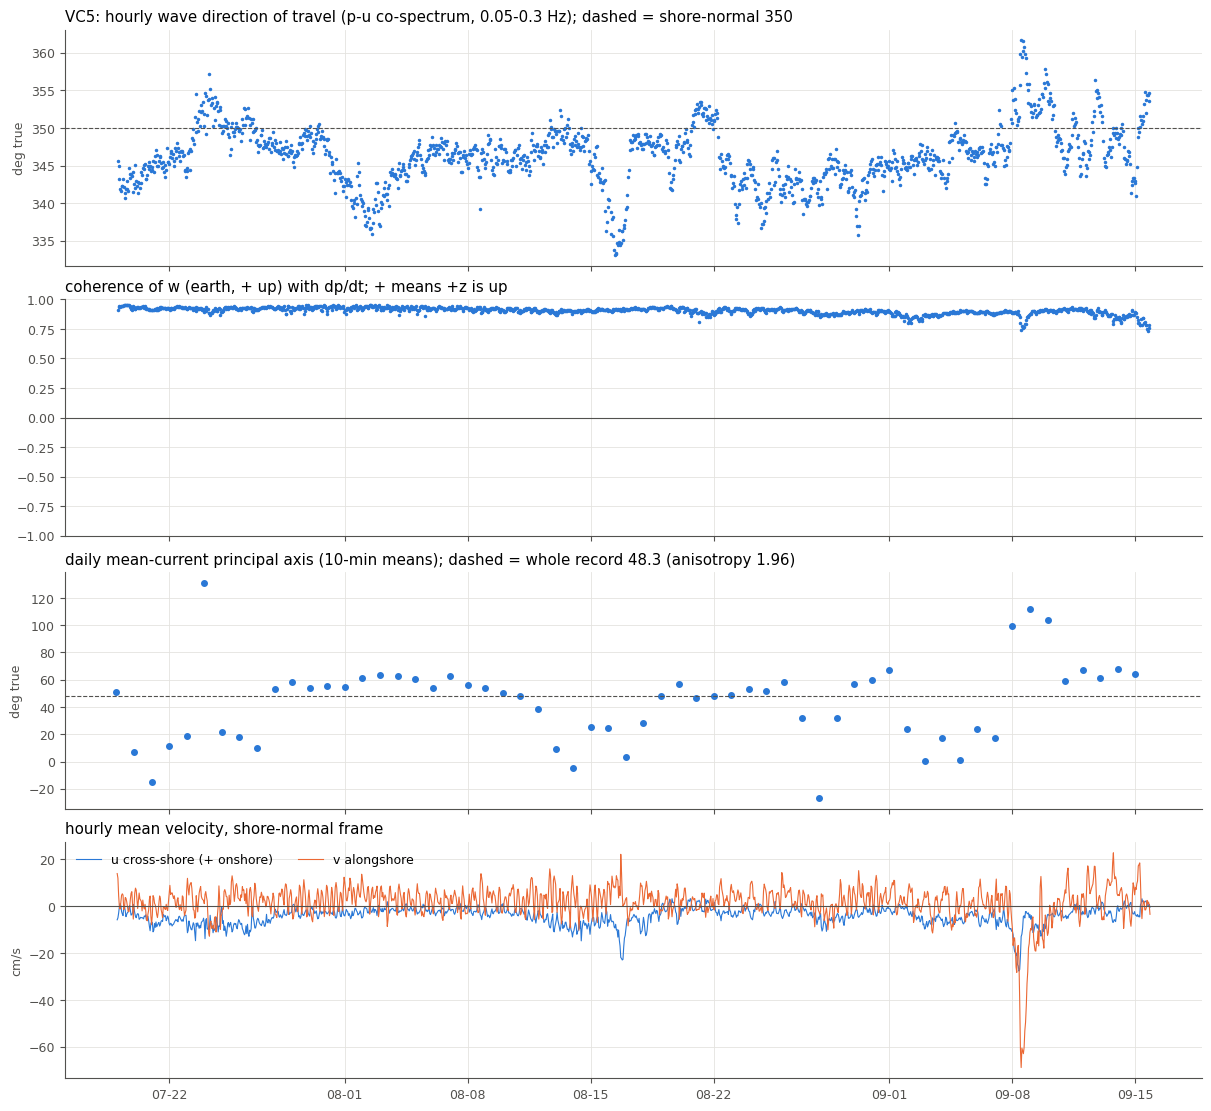

In [16]:
##-----rotation checks: vertical sign, wave direction, current axis-----##
# hourly, over gap-free 1-h segments, wave band 0.05-0.3 Hz
f  = np.fft.rfftfreq(seg_n, 1 / fs)
wb = (f >= 0.05) & (f <= 0.3)
V  = {"E": E, "N": N, "U": Up, "p": rot["p"].values.astype(float)}
rows = []
for h, g in pd.Series(np.arange(n), index=tq).groupby(tq.floor("1h")):
    ii = g.values
    if ii.size != seg_n or any(np.isnan(V[k][ii]).any() for k in V):
        continue
    F = {k: np.fft.rfft(V[k][ii] - V[k][ii].mean())[wb] for k in V}
    co = lambda a, b: np.real(np.sum(F[a] * np.conj(F[b])))
    # 1. w vs dp/dt: in phase (coherence ~ +1) when +z is really up
    Pdot = F["p"] * 1j * 2 * np.pi * f[wb]
    cw = np.real(np.sum(F["U"] * np.conj(Pdot))) / np.sqrt(np.sum(abs(F["U"]) ** 2) * np.sum(abs(Pdot) ** 2))
    # 2. wave direction of travel (bearing, true): horizontal velocity in phase with p points the way waves go
    wdir = np.degrees(np.arctan2(co("E", "p"), co("N", "p"))) % 360
    # 3. wave principal axis (dolfyn, 0-180 deg true) and its anisotropy
    x = np.vstack([V["E"][ii] - V["E"][ii].mean(), V["N"][ii] - V["N"][ii].mean()])
    ev_ = np.linalg.eigvalsh(np.cov(x))
    rows.append((h, cw, wdir, float(calc_principal_heading(x, tidal_mode=True)), np.sqrt(ev_[1] / ev_[0]),
                 np.sqrt(co("p", "p"))))
wv = pd.DataFrame(rows, columns=["hour", "coh_w_dpdt", "wave_dir", "wave_axis", "wave_aniso", "p_amp"]).set_index("hour")

def circ_median_dir(a, w=None):
    # weighted circular mean, deg
    w = np.ones_like(a) if w is None else w
    r = np.radians(a)
    return np.degrees(np.arctan2(np.sum(w * np.sin(r)), np.sum(w * np.cos(r)))) % 360

# daily mean-current principal axis: dolfyn calc_principal_heading on 10-min means (axis, 0-180)
m10 = pd.DataFrame({"E": E, "N": N}, index=tq).resample("10min").mean()
cur = []
for day, g in m10.groupby(m10.index.floor("1D")):
    g = g.dropna()
    if len(g) < 72:                                  # at least half a day of 10-min means
        continue
    x = np.vstack([g.E.values, g.N.values])
    e = np.linalg.eigvalsh(np.cov(x))
    cur.append((day, float(calc_principal_heading(x, tidal_mode=True)), np.sqrt(e[1] / e[0])))
cur = pd.DataFrame(cur, columns=["day", "cur_axis", "cur_aniso"]).set_index("day")
x_all = np.vstack([m10.E.dropna().values, m10.N.dropna().values])
e_all = np.linalg.eigvalsh(np.cov(x_all))
cur_axis_all, cur_aniso_all = float(calc_principal_heading(x_all, tidal_mode=True)), np.sqrt(e_all[1] / e_all[0])

wave_dir_mean = circ_median_dir(wv.wave_dir.values, wv.p_amp.values ** 2)   # energy-weighted
# the normal to the current axis, on the side the waves travel toward (onshore)
cur_normal = min([(cur_axis_all + 90) % 360, (cur_axis_all - 90) % 360],
                 key=lambda a: abs((a - wave_dir_mean + 180) % 360 - 180))
mean_E, mean_N = np.nanmean(E), np.nanmean(N)

print(f"{sensor_id}: {len(wv)} gap-free hours")
print(f"  1. w vs dp/dt coherence: median {wv.coh_w_dpdt.median():+.2f}, "
      f"{100 * (wv.coh_w_dpdt > 0).mean():.0f} % of hours > 0  (expect ~ +1 if +z is up)")
print(f"  2. wave direction of travel: energy-weighted mean {wave_dir_mean:.1f} deg true, hourly 5-95 % "
      f"{np.percentile(wv.wave_dir, 5):.0f}-{np.percentile(wv.wave_dir, 95):.0f}  (expect onshore, ~{SHORE_NORMAL_DEG:g})")
print(f"     wave principal axis: median {wv.wave_axis.median():.1f} deg (anisotropy {wv.wave_aniso.median():.2f})")
print(f"  3. mean-current principal axis (10-min means, whole record): {cur_axis_all:.1f} deg, anisotropy "
      f"{cur_aniso_all:.2f}; daily axis median {cur.cur_axis.median():.1f} (anisotropy {cur.cur_aniso.median():.2f})")
print(f"     normal to that axis, onshore side: {cur_normal:.1f} deg true")
print(f"  mean current: E {100 * mean_E:+.2f}, N {100 * mean_N:+.2f} cm/s -> toward "
      f"{np.degrees(np.arctan2(mean_E, mean_N)) % 360:.0f} deg true; cross-shore {100 * np.nanmean(u_sn):+.2f}, "
      f"alongshore {100 * np.nanmean(v_sn):+.2f} cm/s")
print(f"  shore-normal candidates (onshore, deg true): SHORE_NORMAL_DEG {SHORE_NORMAL_DEG:g} | waves {wave_dir_mean:.1f} "
      f"| current-axis normal {cur_normal:.1f}")

##-----figure-----##
fig, axs = plt.subplots(4, 1, figsize=(12, 11), sharex=True, constrained_layout=True)
ax = axs[0]
# unwrapped to within +-180 of the shore-normal, so a 359 -> 1 deg crossing does not jump
ax.plot(wv.index, (wv.wave_dir - SHORE_NORMAL_DEG + 180) % 360 - 180 + SHORE_NORMAL_DEG, ".", ms=3, color=SERIES)
ax.axhline(SHORE_NORMAL_DEG, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("deg true")
ax.set_title(f"{sensor_id}: hourly wave direction of travel (p-u co-spectrum, 0.05-0.3 Hz); "
             f"dashed = shore-normal {SHORE_NORMAL_DEG:g}", loc="left")
ax = axs[1]
ax.plot(wv.index, wv.coh_w_dpdt, ".", ms=3, color=SERIES)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylim(-1, 1)
ax.set_title("coherence of w (earth, + up) with dp/dt; + means +z is up", loc="left")
ax = axs[2]
# an axis: 5 and 175 deg are 10 deg apart, so plot within +-90 of the whole-record axis
ax.plot(cur.index, (cur.cur_axis - cur_axis_all + 90) % 180 - 90 + cur_axis_all, "o", ms=4, color=SERIES)
ax.axhline(cur_axis_all, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("deg true")
ax.set_title(f"daily mean-current principal axis (10-min means); dashed = whole record {cur_axis_all:.1f} "
             f"(anisotropy {cur_aniso_all:.2f})", loc="left")
ax = axs[3]
m1 = pd.DataFrame({"u": u_sn, "v": v_sn}, index=tq).resample("1h").mean()
ax.plot(m1.index, 100 * m1.u, color=SERIES, lw=0.8, label="u cross-shore (+ onshore)")
ax.plot(m1.index, 100 * m1.v, color="#eb6834", lw=0.8, label="v alongshore")
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylabel("cm/s")
ax.legend(loc="upper left", frameon=False, ncol=2)
ax.set_title("hourly mean velocity, shore-normal frame", loc="left")
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.savefig(fig_dir / f"{sensor_id}_rotate.png", dpi=150)
plt.show()

In [17]:
##-----attach rotation diagnostics-----##
# u, v, w are now shore-normal (u onshore, v alongshore, w up); u_east/v_north are true ENU;
# u_inst/v_inst/w_inst are the head-frame values from section 4. Saved with everything else in section 7.
wv_h = wv.reindex(pd.DatetimeIndex(rot["hour"].values))
for name in ["coh_w_dpdt", "wave_dir", "wave_axis", "wave_aniso"]:
    rot[f"{name}_h"] = ("hour", wv_h[name].values.astype("float32"))
rot["wave_dir_h"].attrs["comment"] = "wave direction of travel, deg true, from the p-u/p-v co-spectra (0.05-0.3 Hz)"
rot.attrs.update({
    "rot_heading_kvh_magnetic_deg": heading_mag,
    "rot_declination_deg": DECLINATION_DEG,
    "rot_declination_source": "WMM-2025 via NOAA NCEI calculator, 2026-08-15, 21.297 N 158.042 W (IGRF-14: 9.27)",
    "rot_heading_true_deg": heading_true,
    "rot_head_up": str(HEAD_UP),
    "rot_head_tilt": "assumed vertical (no head attitude sensor); canister heading/pitch/roll not used",
    "rot_shore_normal_deg": SHORE_NORMAL_DEG,
    "rot_shore_normal_source": ("sensor_notes.csv, transect shoreline heading - 90" if SHORE_NORMAL_OVERRIDE is None
                                else "SHORE_NORMAL_OVERRIDE"),
    "rot_wave_dir_mean_deg": wave_dir_mean,
    "rot_current_axis_deg": cur_axis_all,
    "rot_current_anisotropy": cur_aniso_all,
})


### 6. z² test, linear wave theory (Elgar, Raubenheimer & Guza 2005, §3.3)
Consistency of pressure and velocity. In linear theory the variances of wave-induced pressure $p$ and of cross-
and alongshore velocity ($u$, $v$) at radian frequency $\omega$ are related by Elgar et al. (2005), Eq. (1):
$$z^2 = \frac{p^2}{\left(\frac{\omega}{gk}\right)^2 \frac{\cosh^2(k d_p)}{\cosh^2(k d_u)}\,(u^2+v^2)} = 1,$$
with $\omega^2 = gk\tanh(kh)$, $h$ the water depth, and $d_p$, $d_u$ the heights of the pressure gauge and the
current meter above the seafloor (`Z_P_HAB`, `Z_U_HAB`). For a buried gauge ($d_p < 0$), $\cosh(k d_p)$ is
replaced by $\exp(k d_p)$. Pressure is in m of water.

**Integrated over the wind-wave band, 0.05 < f < 0.20 Hz**, this is the ratio of measured pressure variance to the
pressure variance predicted from $u$ and $v$ (Elgar's Fig. 3):
$$z^2 = \frac{\sum_{0.05}^{0.20} S_{pp}}{\sum_{0.05}^{0.20} (S_{uu}+S_{vv})\,(\omega/gk)^2\,\cosh^2(k d_p)/\cosh^2(k d_u)}$$

**Rejection:** data are rejected unless **0.5 < z² < 2.0** (Elgar et al. 2005). Here each clock hour stands in for
Elgar's 3072-s records. Failing hours get `seg_ok = False`; no samples are removed.
- z² > 1 can come from flow obstruction around the sensor, a sensor inside the wave bottom boundary layer, or a
  sample volume that intersects the bed.
- z² < 1 comes from a noisy velocity record (noise inflates $S_{uu}+S_{vv}$).
- The 0.20 Hz cutoff keeps enough wave signal at both sensors for these depths and heights. Elgar notes it must be
  adjusted with $h$, $d_u$ and $d_p$.


#### 6a. z² per hour

Input is `rot` from section 5 (only $S_{uu}+S_{vv}$ is used, which does not depend on the horizontal frame).
1. Segments are the clock hours of the section 4 hourly table (`tq.floor("1h")`). An hour is used if it is
   nearly complete (≥ 99 % of 3600 s), has no internal time gap > 2 s, and has ≤ `NAN_MAX_FRAC` NaN in p (filled
   linearly). An hour may hold 7199 or 7201 samples, because of the 1-s .vec seam gaps and the drift-corrected clock. Velocity has no
   NaNs after section 4. Incomplete hours, such as the first and last of the record, get no z² and fail `seg_ok`.
2. Each hour is **linearly detrended**, then Welch spectra: `ZT_NFFT` (128 s) Hann windows, 50 % overlap
   (~55 windows, ~100 dof; Elgar's estimates had ~60).
3. k from the full dispersion relation at h = mean p + `Z_P_HAB`; z² from Eq. (1) summed over `ZT_F_Z2`
   (0.05–0.20 Hz); `z2_ok = 0.5 < z² < 2.0`; **`seg_ok = seg_runmean_ok & z2_ok`**.
4. Diagnostics, not gates:
   - `z2_IG` uses the same formula over the IG band. It has only ~5 bins, and bound IG waves are not free waves.
   - `Hs_SS` comes from the pressure spectrum over 0.04–0.25 Hz, depth-corrected.
   - The record median z² gives `zt_status`.
5. A synthetic linear wave is run through the same code first. z² must come out as 1 (within 2 %), also with p
   and u at different heights, or the cell stops.


In [18]:
##-----z^2 test (Elgar, Raubenheimer & Guza 2005, section 3.3): measured vs velocity-predicted pressure variance-----##
from scipy.signal import welch, detrend

def wavenumber(omega, h, g=GRAV):
    """k from omega^2 = g k tanh(k h) (Newton, vectorized). omega > 0."""
    omega = np.asarray(omega, float)
    k = np.maximum(omega ** 2 / g, omega / np.sqrt(g * h))       # deep / shallow-water start
    for _ in range(40):
        th = np.tanh(k * h)
        k = k - (g * k * th - omega ** 2) / (g * th + g * k * h * (1 - th ** 2))
    return k

def seg_spectra(p_m, u, v):
    """Welch spectra of one segment, after a linear detrend of the whole segment."""
    kw = dict(fs=fs, window="hann", nperseg=ZT_NFFT, noverlap=int(ZT_NFFT * ZT_OVERLAP), detrend=False)
    f, Spp = welch(detrend(p_m, type="linear"), **kw)
    _, Suu = welch(detrend(u, type="linear"), **kw)
    _, Svv = welch(detrend(v, type="linear"), **kw)
    return f, Spp, Suu + Svv

def z2_from_spectra(f, Spp, Suv, h, z_p, z_u, band):
    """Elgar et al. (2005) Eq. (1), integrated over `band`:
        z^2 = sum(Spp) / sum(Spp_pred),   Spp_pred = (Suu + Svv) (omega / g k)^2 Cp^2 / cosh^2(k z_u)
    with Cp = cosh(k z_p), or exp(k z_p) for a buried gauge (z_p < 0). p in m of water; z_p, z_u above the bed.
    Also returns S_eta = Spp (cosh(k h) / Cp)^2 (for Hs) and Spp_pred. Arrays may carry a leading segment axis."""
    b = (f >= band[0]) & (f <= band[1])
    om = 2 * np.pi * f[b]
    h = np.atleast_1d(h)[:, None]
    k = wavenumber(om[None, :], h)
    Cp = np.exp(k * z_p) if z_p < 0 else np.cosh(k * z_p)
    pred = np.atleast_2d(Suv)[:, b] * (om / (GRAV * k)) ** 2 * (Cp / np.cosh(k * z_u)) ** 2
    Spp_b = np.atleast_2d(Spp)[:, b]
    S_eta = Spp_b * (np.cosh(k * h) / Cp) ** 2
    return np.sum(Spp_b, 1) / np.sum(pred, 1), S_eta, pred

# closure check on a synthetic linear wave (one hour): z^2 must come out 1, also with p and u at different heights
_t = np.arange(int(3600 * fs)) / fs
for _h, _zp, _zu in [(5.0, 0.2, 0.2), (10.0, 0.2, 0.8)]:
    _p = np.zeros_like(_t); _u = np.zeros_like(_t)
    for _f, _a in [(0.07, 0.3), (0.10, 0.5), (0.15, 0.3)]:
        _om = 2 * np.pi * _f; _k = float(wavenumber(_om, _h)); _ph = np.random.default_rng(1).uniform(0, 2 * np.pi)
        _p += _a * np.cosh(_k * _zp) / np.cosh(_k * _h) * np.cos(_om * _t + _ph)
        _u += _a * _om * np.cosh(_k * _zu) / np.sinh(_k * _h) * np.cos(_om * _t + _ph)
    _f_, _S, _Suv = seg_spectra(_p, _u, 0 * _u)
    _z = z2_from_spectra(_f_, _S, _Suv, _h, _zp, _zu, ZT_F_Z2)[0][0]
    assert abs(_z - 1) < 0.02, f"z^2 closure failed: {_z:.3f} at h {_h}, z_p {_zp}, z_u {_zu}"

# per-hour spectra, on the clock hours of the section 4 table. Input: `rot` from section 5.
z_p = Z_P_HAB
z_u = Z_P_HAB if Z_U_HAB is None else Z_U_HAB
P_all = rot["p"].values.astype(float) * 1e4 / (RHO * GRAV)       # dbar -> m of water
U_all, V_all = rot["u"].values.astype(float), rot["v"].values.astype(float)
hours = pd.DatetimeIndex(rot["hour"].values)
rows, spp, suv = [], [], []
for h, g in pd.Series(np.arange(n), index=tq).groupby(tq.floor("1h")):
    ii = g.values
    max_gap = np.diff(tq[ii].values).max() / np.timedelta64(1, "s") if ii.size > 1 else np.inf
    X = [P_all[ii], U_all[ii], V_all[ii]]
    nan_frac = max(np.isnan(a).mean() for a in X)
    # a (nearly) complete hour, no internal gap > 2 s, p mostly valid (velocity has no NaN after section 4).
    # Not "exactly seg_n": a 1-s .vec seam gap or the drift-corrected clock leaves 7199/7201 samples in an hour.
    if ii.size < 0.99 * seg_n or max_gap > 2.0 or nan_frac > NAN_MAX_FRAC:
        rows.append((h, np.nan, nan_frac, False))
        continue
    X = [pd.Series(a).interpolate(limit_direction="both").values for a in X]
    f_z, S1, S2 = seg_spectra(*X)
    rows.append((h, np.mean(X[0]) + z_p, nan_frac, True))       # total depth, bed to surface
    spp.append(S1); suv.append(S2)
zt = pd.DataFrame(rows, columns=["hour", "h", "nan_frac", "ok"]).set_index("hour").reindex(hours)
zt["ok"] = zt["ok"].fillna(False).astype(bool)                   # hours with no samples at all
ok = zt["ok"].values
Spp = np.vstack(spp); Suv = np.vstack(suv)
h_ok = zt["h"].values[ok]

z2 = z2_from_spectra(f_z, Spp, Suv, h_ok, z_p, z_u, ZT_F_Z2)[0]
z2_ig = z2_from_spectra(f_z, Spp, Suv, h_ok, z_p, z_u, ZT_F_IG)[0]
S_eta_ss = z2_from_spectra(f_z, Spp, Suv, h_ok, z_p, z_u, ZT_F_SS)[1]
df_z = f_z[1] - f_z[0]
zt.loc[ok, "z2"] = z2
zt.loc[ok, "z2_IG"] = z2_ig
zt.loc[ok, "Hs_SS"] = 4 * np.sqrt(S_eta_ss.sum(1) * df_z)
zt["z2_ok"] = (zt["z2"] > ZT_WINDOW[0]) & (zt["z2"] < ZT_WINDOW[1])   # no z^2 (NaN) -> False

# the gate (Elgar et al. 2005): an hour is good only if 0.5 < z^2 < 2.0, on top of the section 4 running-mean test
runmean_ok = rot["seg_runmean_ok"].values
seg_ok = runmean_ok & zt["z2_ok"].values
rot["z2_ok"] = ("hour", zt["z2_ok"].values,
                {"long_name": f"{ZT_WINDOW[0]} < z^2 < {ZT_WINDOW[1]} (Elgar et al. 2005); False where no z^2"})
rot["seg_ok"] = ("hour", seg_ok,
                 {"long_name": f"good hour: running mean <= {100 * RUNMEAN_MAX_FRAC:g} % AND "
                               f"{ZT_WINDOW[0]} < z^2 < {ZT_WINDOW[1]}"})

# record-level summary (median z^2 in the window)
zmed = float(np.nanmedian(z2))
if ok.sum() < ZT_MIN_SEG:
    z_status = "insufficient"
elif ZT_WINDOW[0] < zmed < ZT_WINDOW[1]:
    z_status = "ok"
else:
    z_status = "FLAG"
z_fail = ok & ~zt["z2_ok"].values

print(f"{sensor_id}: z^2 (Elgar et al. 2005 Eq. 1) in {ok.sum()} of {len(zt)} 1-h segments; Welch {ZT_NFFT / fs:g} s "
      f"Hann, {100 * ZT_OVERLAP:g} % overlap, df {df_z:.4f} Hz; d_p {z_p:.2f} m, d_u {z_u:.2f} m above bed")
print(f"  z^2 ({ZT_F_Z2[0]}-{ZT_F_Z2[1]} Hz): median {zmed:.3f}, 5-95 % {np.percentile(z2, 5):.3f}-"
      f"{np.percentile(z2, 95):.3f}; outside {ZT_WINDOW}: {z_fail.sum()} hours "
      f"({', '.join(f'{h:%m-%d %H}h' for h in hours[z_fail][:8])}) -> record {z_status}")
print(f"  no z^2 (< 99 % of an hour, gap > 2 s, or p NaN > {100 * NAN_MAX_FRAC:g} %): {(~ok).sum()} hours "
      f"({', '.join(f'{h:%m-%d %H}h' for h in hours[~ok][:8])}{' ...' if (~ok).sum() > 8 else ''})")
print(f"  seg_ok = running mean <= {100 * RUNMEAN_MAX_FRAC:g} % AND {ZT_WINDOW[0]} < z^2 < {ZT_WINDOW[1]}: "
      f"{seg_ok.sum()} of {len(seg_ok)} hours pass (running-mean fails {(~runmean_ok).sum()}, "
      f"z^2 fails or missing {(~zt['z2_ok'].values).sum()})")
print(f"  z2_IG ({ZT_F_IG[0]}-{ZT_F_IG[1]} Hz, {int(((f_z >= ZT_F_IG[0]) & (f_z <= ZT_F_IG[1])).sum())} bins): "
      f"median {np.nanmedian(z2_ig):.3f}   (diagnostic: few bins; bound IG waves are not linear free waves)")
hs_t = np.nanpercentile(zt.Hs_SS, [33, 67])
for lab, m in [("small", zt.Hs_SS < hs_t[0]), ("mid", (zt.Hs_SS >= hs_t[0]) & (zt.Hs_SS < hs_t[1])), ("large", zt.Hs_SS >= hs_t[1])]:
    print(f"  Hs_SS {lab:5s} ({zt.Hs_SS[m].min():.2f}-{zt.Hs_SS[m].max():.2f} m): median z^2 {zt.z2[m].median():.3f}")
# the heights are estimates; how much would a different velocity height change z^2?
sens = {dz: float(np.nanmedian(z2_from_spectra(f_z, Spp, Suv, h_ok, z_p, max(z_u + dz, 0), ZT_F_Z2)[0]))
        for dz in (-0.2, 0.2, 0.5)}
print("  height sensitivity, median z^2 if d_u were: " +
      ", ".join(f"{z_u + dz:.2f} m -> {v:.3f}" for dz, v in sens.items()))


VC5: z^2 (Elgar et al. 2005 Eq. 1) in 1410 of 1412 1-h segments; Welch 128 s Hann, 50 % overlap, df 0.0078 Hz; d_p 0.05 m, d_u 0.05 m above bed
  z^2 (0.05-0.2 Hz): median 0.941, 5-95 % 0.895-0.998; outside (0.5, 2.0): 0 hours () -> record ok
  no z^2 (< 99 % of an hour, gap > 2 s, or p NaN > 10 %): 2 hours (07-19 01h, 09-15 20h)
  seg_ok = running mean <= 10 % AND 0.5 < z^2 < 2.0: 1409 of 1412 hours pass (running-mean fails 1, z^2 fails or missing 2)
  z2_IG (0.004-0.04 Hz, 5 bins): median 0.813   (diagnostic: few bins; bound IG waves are not linear free waves)
  Hs_SS small (0.50-0.93 m): median z^2 0.932
  Hs_SS mid   (0.93-1.23 m): median z^2 0.940
  Hs_SS large (1.23-2.29 m): median z^2 0.956
  height sensitivity, median z^2 if d_u were: -0.15 m -> 0.941, 0.25 m -> 0.942, 0.55 m -> 0.944


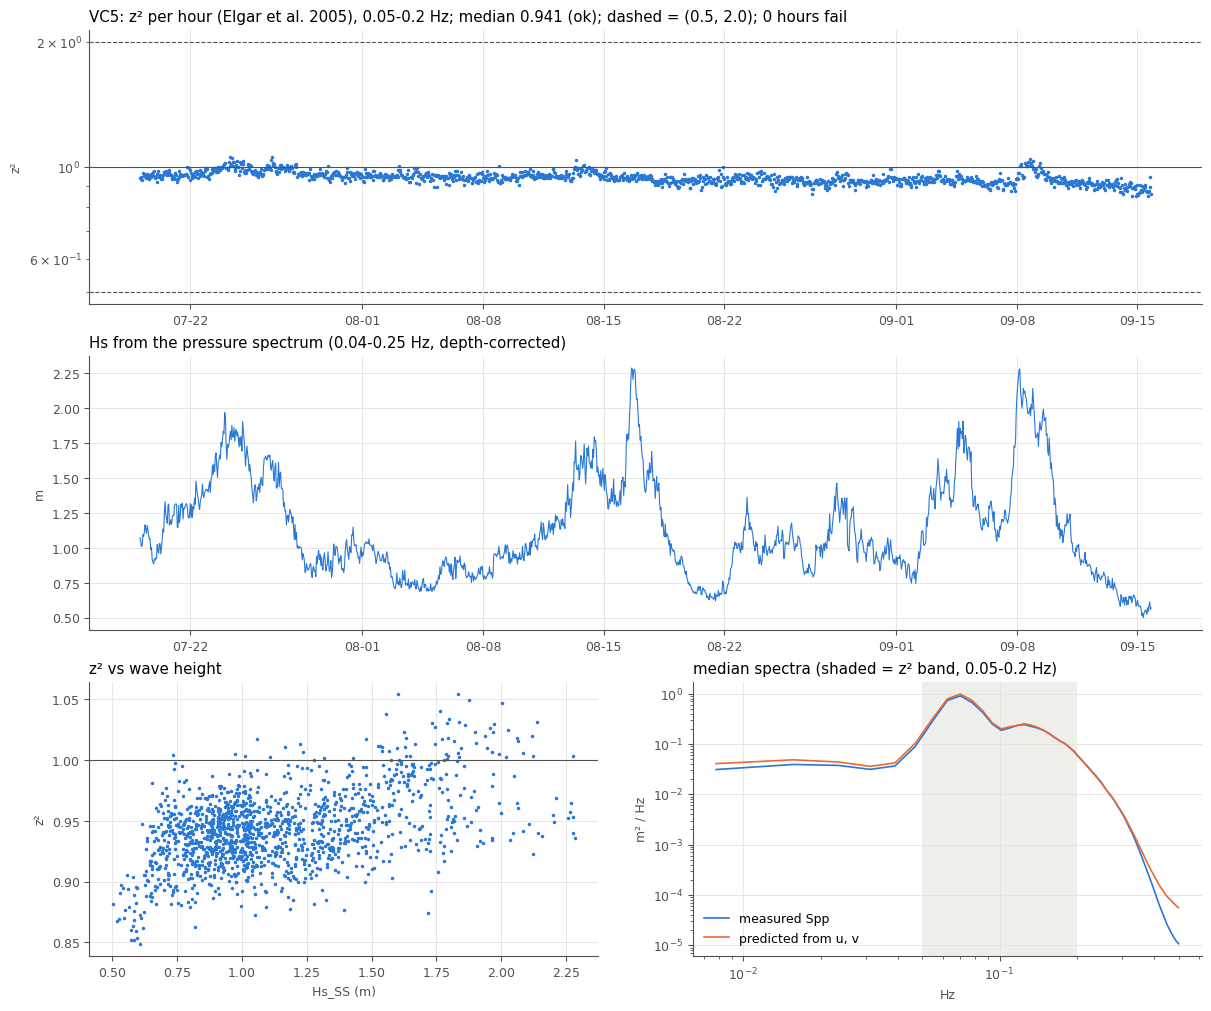

In [19]:
##-----figure: z^2 test-----##
fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(3, 2)
ax = fig.add_subplot(gs[0, :])
ax.plot(zt.index, zt.z2, ".", ms=3, color=SERIES)
ax.plot(zt.index[z_fail], zt.z2[z_fail], "o", ms=4, color="#eb6834", label="fails 0.5 < z² < 2")
ax.axhline(1, color=INK2, lw=0.8)
for y in ZT_WINDOW:
    ax.axhline(y, color=INK2, ls="--", lw=0.8)
ax.set_yscale("log")
ax.set_ylabel("z²")
ax.set_title(f"{sensor_id}: z² per hour (Elgar et al. 2005), {ZT_F_Z2[0]}-{ZT_F_Z2[1]} Hz; "
             f"median {zmed:.3f} ({z_status}); dashed = {ZT_WINDOW}; {z_fail.sum()} hours fail", loc="left")
if z_fail.any():
    ax.legend(frameon=False, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax2 = fig.add_subplot(gs[1, :], sharex=ax)
ax2.plot(zt.index, zt.Hs_SS, color=SERIES, lw=0.8)
ax2.set_ylabel("m")
ax2.set_title(f"Hs from the pressure spectrum ({ZT_F_SS[0]}-{ZT_F_SS[1]} Hz, depth-corrected)", loc="left")
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(zt.Hs_SS, zt.z2, ".", ms=3, color=SERIES)
ax3.axhline(1, color=INK2, lw=0.8)
ax3.set_xlabel("Hs_SS (m)")
ax3.set_ylabel("z²")
ax3.set_title("z² vs wave height", loc="left")
ax4 = fig.add_subplot(gs[2, 1])
b = (f_z > 0) & (f_z <= 0.5)
om = 2 * np.pi * f_z[b]
k_med = wavenumber(om, np.median(h_ok))
pred_med = np.median(Suv[:, b], 0) * (om / (GRAV * k_med)) ** 2 * (np.cosh(k_med * z_p) / np.cosh(k_med * z_u)) ** 2
ax4.loglog(f_z[b], np.median(Spp[:, b], 0), color=SERIES, lw=1.2, label="measured Spp")
ax4.loglog(f_z[b], pred_med, color="#eb6834", lw=1.2, label="predicted from u, v")
ax4.axvspan(*ZT_F_Z2, color=GRID, alpha=0.6, lw=0)
ax4.set_xlabel("Hz")
ax4.set_ylabel("m² / Hz")
ax4.legend(frameon=False, loc="lower left")
ax4.set_title(f"median spectra (shaded = z² band, {ZT_F_Z2[0]}-{ZT_F_Z2[1]} Hz)", loc="left")
fig.savefig(fig_dir / f"{sensor_id}_ztest.png", dpi=150)
plt.show()


### 7. Final product: `{sensor}_QC.nc`
Everything from sections 1-6 in one file, `data/processed/qc/{sensor}_QC.nc`:
- 2 Hz (`time`): `u`, `v`, `w` (shore-normal), `u_east`, `v_north`, `u_inst`/`v_inst`/`w_inst`, `p`, `p_raw`, `patm`,
  `temp`, `corr`, `amp`, canister `heading`/`pitch`/`roll`, flags `vel_corr_ok`, `vel_low_snr`, `vel_qc_flag` (0 good, 1 linear interp, 2 1-s running mean; Elgar et al. 2005).
- hourly (`hour`): `seg_ok` (= `seg_runmean_ok` AND `z2_ok`), `seg_interp_pct`, `seg_runmean_pct`, `seg_runmean_ok`,
  `seg_snr_low_pct`, `seg_snr_ok`, z² test `z2`, `z2_ok`, `z2_IG`, `Hs_SS`, `depth_h`, wave/rotation diagnostics (`*_h`).
- median spectra of the z² hours on `freq`: `Spp_median`, `SuuSvv_median`.
- global attributes: every QC choice (`qc_*`, `rot_*`, `zt_*`).


In [20]:
##-----save: final QC product-----##
# z^2 results go on the hourly dim of the section 4 table; median spectra on "freq"
zds = xr.Dataset(
    {"z2": ("hour", zt.z2.values.astype("float32"),
            {"long_name": f"z^2: measured / velocity-predicted pressure variance, {ZT_F_Z2[0]}-{ZT_F_Z2[1]} Hz "
                          "(Elgar et al. 2005 Eq. 1)"}),
     "z2_IG": ("hour", zt.z2_IG.values.astype("float32"), {"long_name": "z^2 over the IG band, diagnostic"}),
     "Hs_SS": ("hour", zt.Hs_SS.values.astype("float32"),
               {"units": "m", "long_name": f"Hs from the pressure spectrum, {ZT_F_SS[0]}-{ZT_F_SS[1]} Hz"}),
     "depth_h": ("hour", zt.h.values.astype("float32"), {"units": "m", "long_name": "mean p (m) + z_p"}),
     "Spp_median": ("freq", np.median(Spp, 0).astype("float32"), {"units": "m2 Hz-1"}),
     "SuuSvv_median": ("freq", np.median(Suv, 0).astype("float32"), {"units": "m2 s-2 Hz-1"})},
    coords={"hour": rot["hour"].values, "freq": f_z})
qc = xr.merge([rot, zds], combine_attrs="override")
qc.attrs.update({"zt_method": "Elgar, Raubenheimer & Guza 2005 (Meas. Sci. Technol. 16), section 3.3",
                 "zt_segment": "1 h, clock-aligned (hour dim)", "zt_welch_nfft": ZT_NFFT, "zt_welch_overlap": ZT_OVERLAP,
                 "zt_detrend": "linear, per hour", "zt_band_z2_hz": list(ZT_F_Z2), "zt_band_hs_hz": list(ZT_F_SS),
                 "zt_band_ig_hz": list(ZT_F_IG), "zt_z_p_m": z_p, "zt_z_u_m": z_u, "zt_window": list(ZT_WINDOW),
                 "zt_median_z2": zmed, "zt_status": z_status, "zt_n_hours": int(ok.sum()),
                 "zt_z2_fail_hours": int(z_fail.sum()), "zt_seg_ok_pct": float(100 * seg_ok.mean()),
                 "zt_formula": ("z^2 = sum(Spp) / sum((Suu+Svv)(w/gk)^2 cosh^2(k d_p)/cosh^2(k d_u)) over the band; "
                                "exp(k d_p) if d_p < 0"),
                 "sensor_id": sensor_id,
                 "qc_notebook": "processing/adv_QC.ipynb"})
# zlib on every data variable (level 4); time listed explicitly, since replacing the coordinate (drift
# correction) dropped its compression settings
enc = {v: {"zlib": True, "complevel": 4} for v in qc.data_vars}
enc["time"] = {"zlib": True, "complevel": 4}
out_path = qc_dir / f"{sensor_id}_QC.nc"
qc.to_netcdf(out_path, encoding=enc)
print(f"saved {out_path}  ({out_path.stat().st_size / 1e9:.2f} GB)")


saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/VC5_QC.nc  (0.35 GB)


### Run the other sensors
Off by default. Once the pipeline is verified on VC5:
1. fill `SENSORS` in the parameters cell (section 0),
2. save the notebook (the batch cell reads it from disk),
3. set `RUN_BATCH = True` in the cell below and run that cell on its own.

Each sensor runs in a fresh kernel, with `sensor_id` overridden. The executed copy, with all
printed QC numbers and figures, goes to `processing/qc_runs/adv_QC_{sensor}.ipynb`, so each sensor
can be reviewed the same way VC5 was. Thresholds tuned on VC5/VC10 (e.g. `HEAD_STD_MAX`) should be
checked in each copy.